In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
FFT_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_corrected_FFT2\images\angles.csv"
HOUGH_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_corrected_hough2\images\angles.csv"
GT_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\labels.csv"
CNN_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_cnn\angles.csv"

In [3]:
FFT_df= pd.read_csv(FFT_ROOT)
HOUGH_df= pd.read_csv(HOUGH_ROOT)
GT_df = pd.read_csv(GT_ROOT)
CNN_df = pd.read_csv(CNN_ROOT)

FFT_df.describe(),HOUGH_df.describe(),GT_df.describe(),CNN_df.describe()

(       fringe_angle_deg  rotation_deg
 count       1000.000000   1000.000000
 mean          -1.317917      0.662083
 std           51.276557     53.086430
 min          -89.719322    -89.997270
 25%          -43.551293    -46.933151
 50%           -1.860337      1.508397
 75%           41.595655     48.114648
 max           89.815186     89.834437,
        fringe_angle_deg  vertical_error_deg  rotation_deg
 count       1000.000000         1000.000000   1000.000000
 mean          -2.411136           -2.088864      2.088864
 std           50.555764           53.401416     53.401416
 min          -89.972659          -90.000000    -89.991337
 25%          -44.309079          -48.408634    -45.359045
 50%           -2.863145           -3.483740      3.483740
 75%           40.514882           45.359045     48.408634
 max           89.799150           89.991337     90.000000,
          angle_deg    n_fringes
 count  1000.000000  1000.000000
 mean     46.792901    17.613607
 std      51.7631

In [4]:
FFT_angles = FFT_df['rotation_deg'].values
HOUGH_angles = HOUGH_df['rotation_deg'].values
GT_angles = GT_df['angle_deg'].values
CNN_angles = CNN_df['predicted_angle'].values

In [5]:
FFT_angles,HOUGH_angles,GT_angles,CNN_angles

(array([ 84.6573864 ,  56.47226933, -33.43211384, -12.15790111,
         50.84299555,  10.11363173, -38.29055048, -56.34551422,
        -33.02884536,  56.87030181,  23.9023069 ,  83.87878203,
         29.67424888,  75.93519223, -63.58046677, -27.68162865,
         75.58128363,   6.04544615,  72.8744312 ,  52.86986818,
        -48.44934316, -58.8586142 ,  71.84917832, -88.4082732 ,
         54.8678858 , -18.87038655,  26.75156025, -62.24401981,
          5.7199013 ,   6.60108908,  50.76896295,  81.56688083,
         67.90347462,  69.84941948,  39.43764162,   4.32031308,
        -58.59780322, -10.12969337,  44.43230544, -70.90788927,
         -6.69165475,  -1.8701686 , -48.26292416, -60.92489715,
        -25.59268466, -60.88681438,  37.28724908, -27.24576858,
        -88.87193626,  69.43753006,  14.78311816,  19.98854832,
        -53.60401857,  79.66860637,  49.10920729,  20.61362009,
        -46.03981558,  -6.89742912,   0.90298583,  61.98151336,
        -10.07898492, -42.69677255, -70.

In [6]:
import numpy as np
from sklearn.metrics import r2_score

def angular_error(pred, gt):
    """
    Circular angular error for orientations.
    Returns error in [-90, 90) degrees.
    """
    return (pred - gt + 90) % 180 - 90

In [7]:
def evaluate(pred, gt, name="Method"):
    err = angular_error(np.asarray(pred), np.asarray(gt))

    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err**2))
    median = np.median(np.abs(err))
    std = np.std(err)

    within_05 = np.mean(np.abs(err) <= 0.5) * 100
    within_1 = np.mean(np.abs(err) <= 1.0) * 100
    within_2 = np.mean(np.abs(err) <= 2.0) * 100
    within_5 = np.mean(np.abs(err) <= 5.0) * 100

    # Circularly corrected prediction for R²
    pred_corrected = gt + err
    r2 = r2_score(gt, pred_corrected)

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE            : {mae:.3f}°")
    print(f"RMSE           : {rmse:.3f}°")
    print(f"Median Error   : {median:.3f}°")
    print(f"Std Error      : {std:.3f}°")
    print(f"R² Score       : {r2:.5f}")
    print(f"Within 0.5°    : {within_05:.2f}%")
    print(f"Within 1°      : {within_1:.2f}%")
    print(f"Within 2°      : {within_2:.2f}%")
    print(f"Within 5°      : {within_5:.2f}%")

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Median": median,
        "Std": std,
        "R2": r2,
        "Within0.5": within_05,
        "Within1": within_1,
        "Within2": within_2,
        "Within5": within_5,
    }

In [8]:
fft_metrics = evaluate(FFT_angles, GT_angles, "FFT")
hough_metrics = evaluate(HOUGH_angles, GT_angles, "HOUGH")
CNN_metrics = evaluate(CNN_angles, GT_angles, "CNN")


FFT
----------------------------------------
MAE            : 14.973°
RMSE           : 27.267°
Median Error   : 3.000°
Std Error      : 27.267°
R² Score       : 0.72223
Within 0.5°    : 18.10%
Within 1°      : 30.90%
Within 2°      : 43.30%
Within 5°      : 57.40%

HOUGH
----------------------------------------
MAE            : 1.332°
RMSE           : 6.195°
Median Error   : 0.165°
Std Error      : 6.194°
R² Score       : 0.98566
Within 0.5°    : 78.00%
Within 1°      : 84.60%
Within 2°      : 89.70%
Within 5°      : 95.50%

CNN
----------------------------------------
MAE            : 1.076°
RMSE           : 2.171°
Median Error   : 0.606°
Std Error      : 2.168°
R² Score       : 0.99824
Within 0.5°    : 43.50%
Within 1°      : 68.00%
Within 2°      : 88.60%
Within 5°      : 97.50%


In [11]:
err_Hough=angular_error(HOUGH_angles, GT_angles)
err_FFT=angular_error(FFT_angles, GT_angles)
err_CNN=angular_error(CNN_angles, GT_angles)

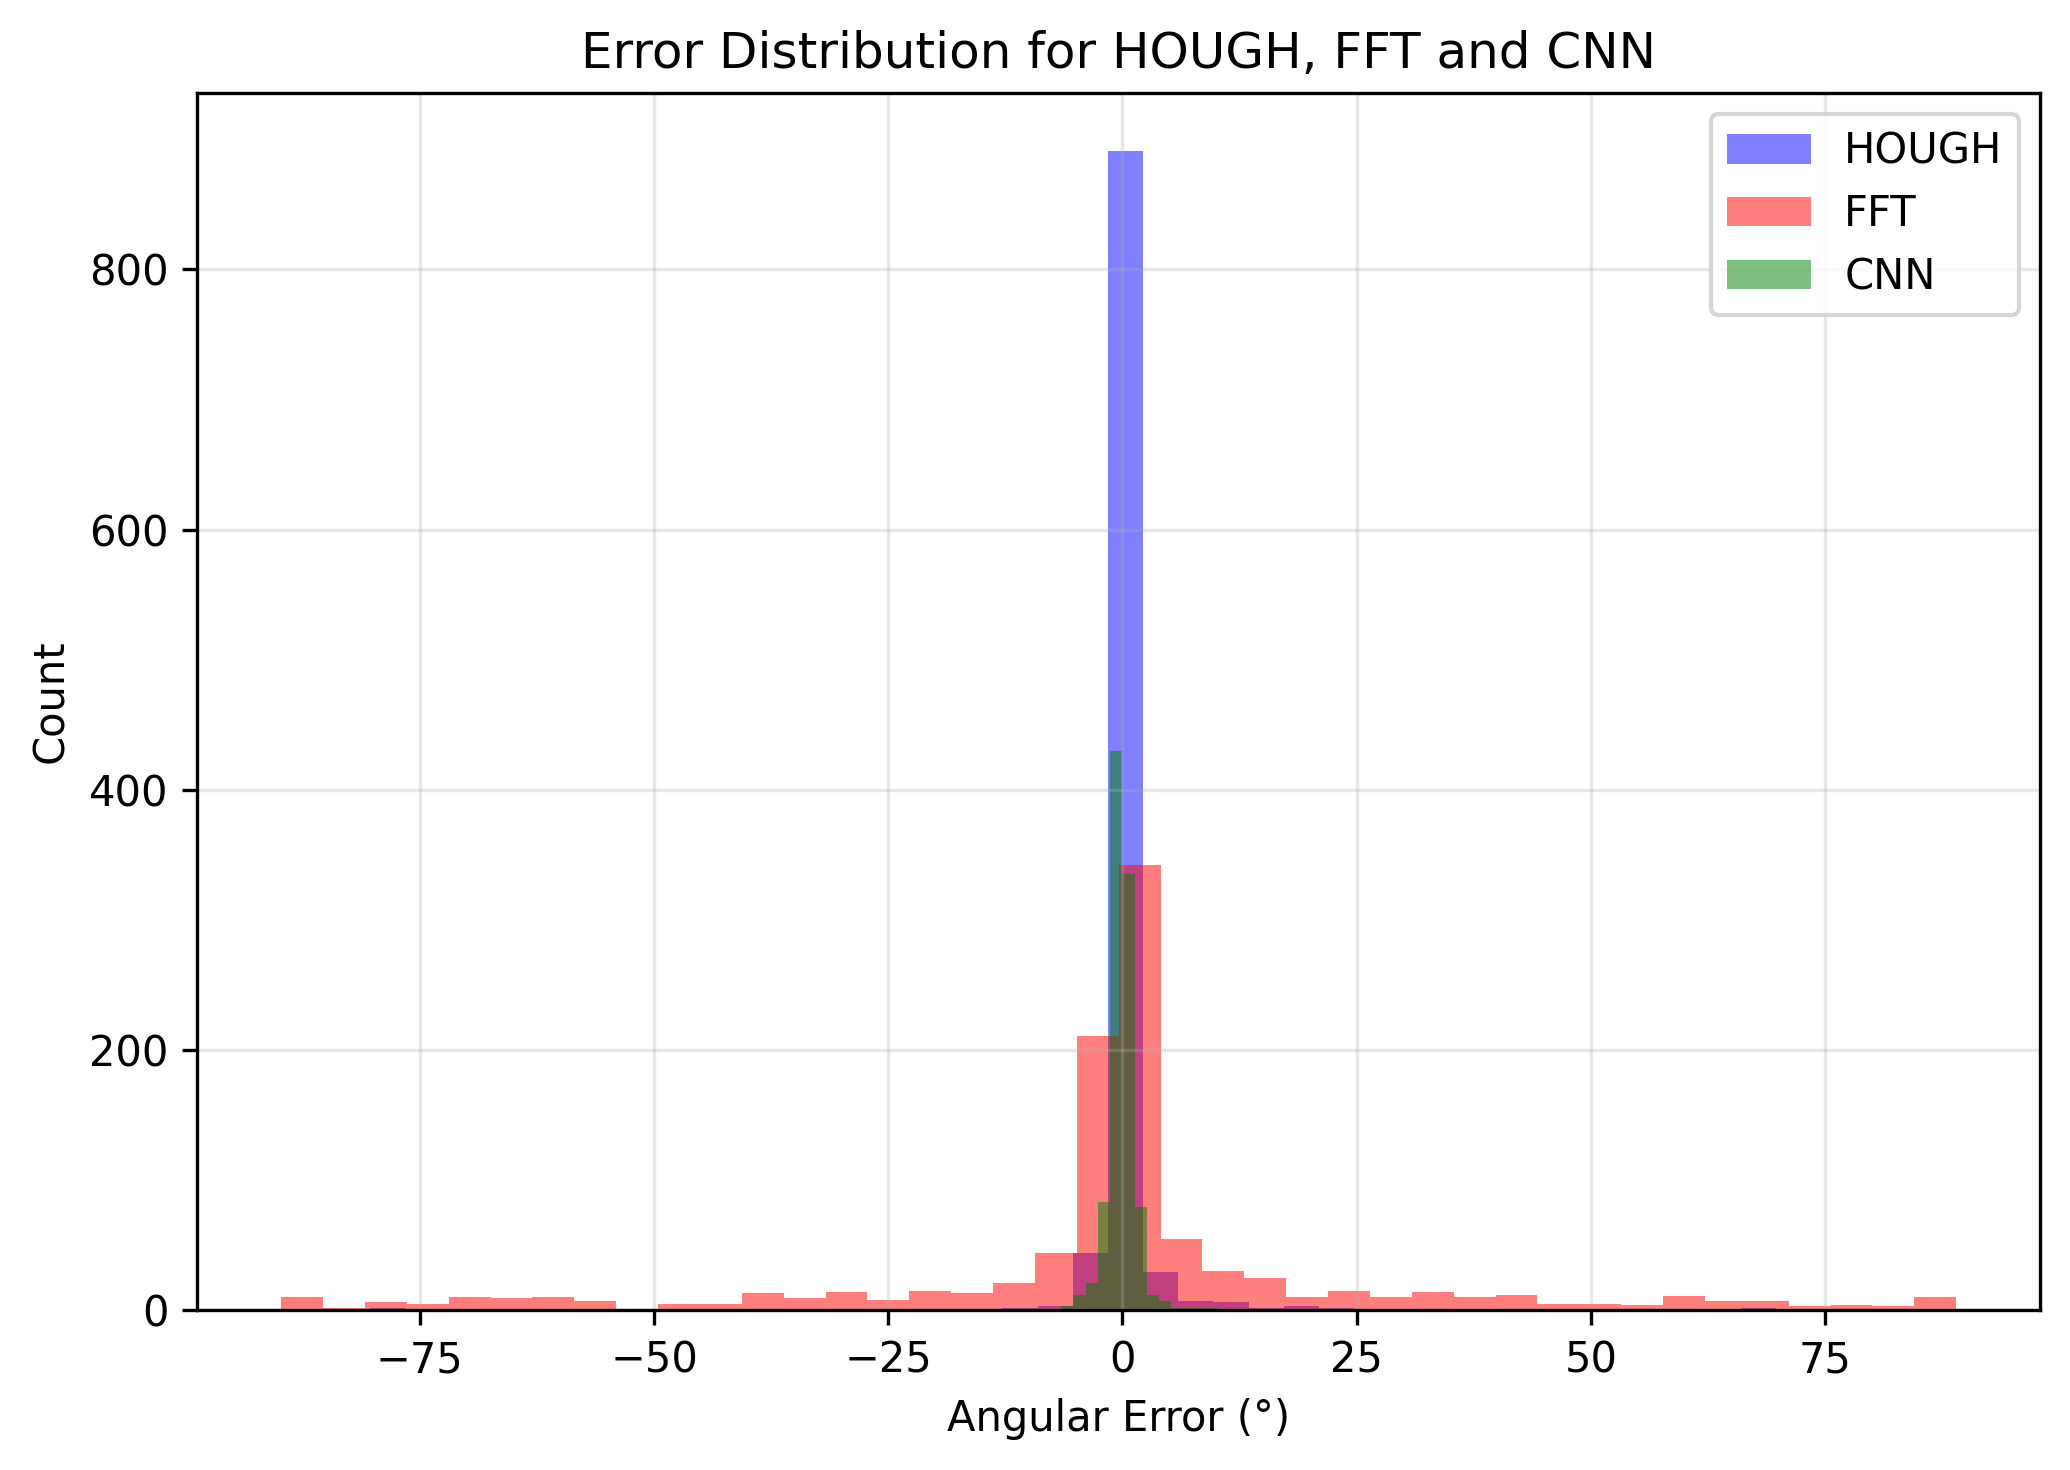

In [12]:
plt.figure(figsize=(7, 5), dpi=300)
plt.hist(err_Hough, bins=40, alpha=0.5, label='HOUGH', color='blue')
plt.hist(err_FFT, bins=40, alpha=0.5, label='FFT', color='red')
plt.hist(err_CNN, bins=40, alpha=0.5, label='CNN', color='green')
plt.xlabel("Angular Error (°)")
plt.ylabel("Count")
plt.title("Error Distribution for HOUGH, FFT and CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("error_distribution.png", dpi=300)
plt.show()


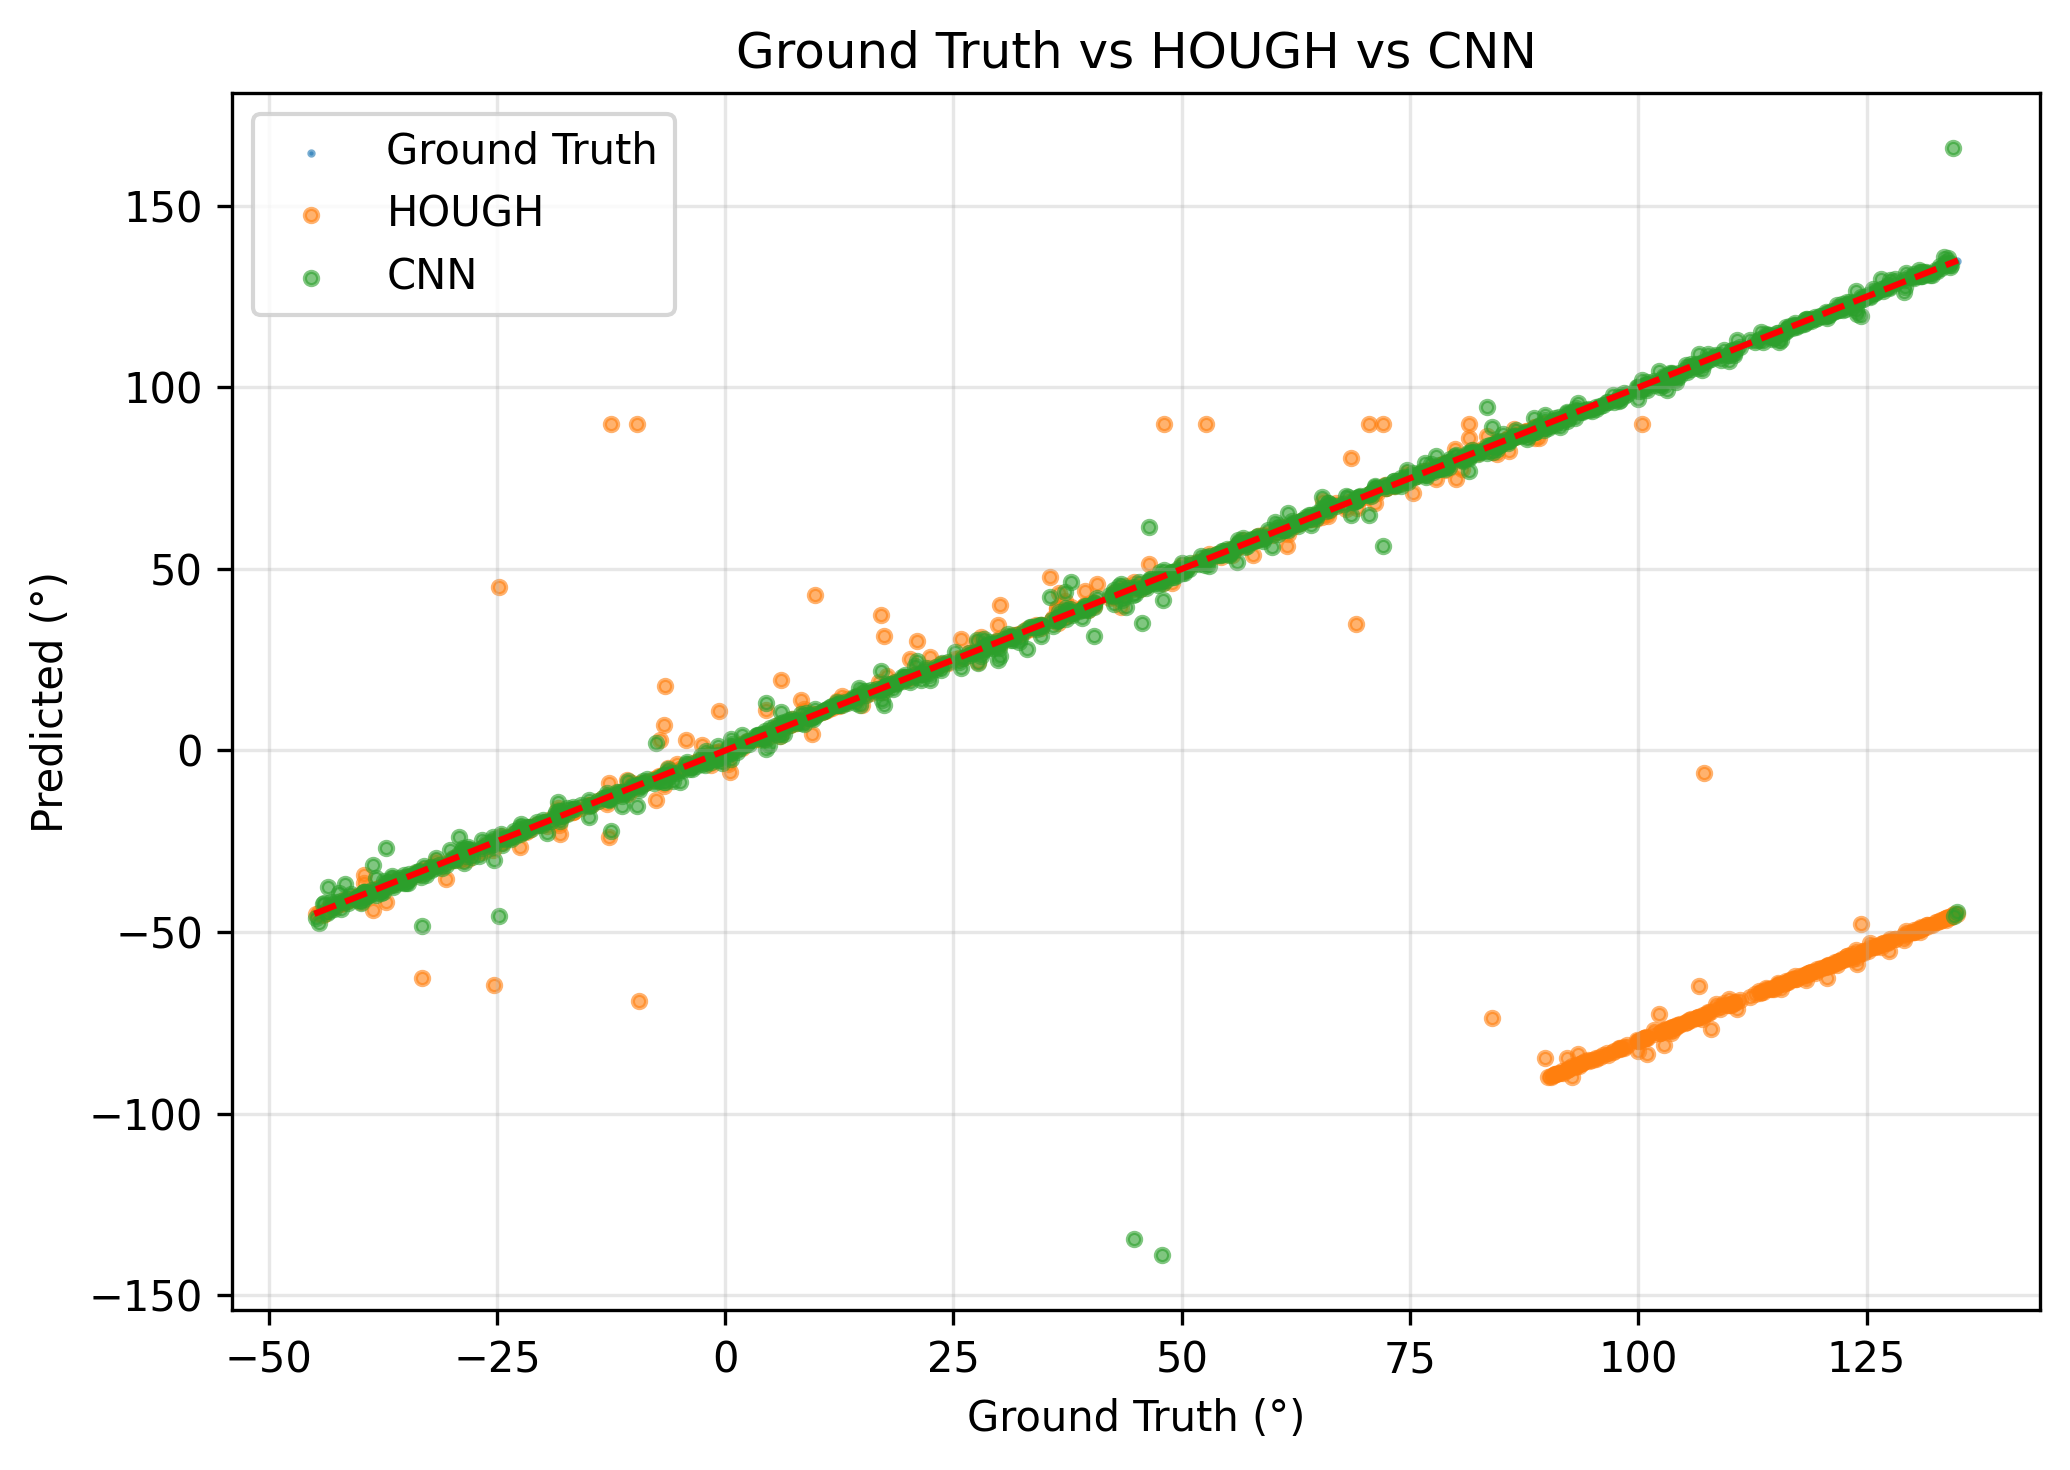

In [17]:
plt.figure(figsize=(7, 5), dpi=300)
# plt.scatter(GT_angles, FFT_angles, s=10, alpha=0.6) 
plt.scatter(GT_angles, GT_angles, s=1, alpha=0.6)  # Ground Truth line
plt.scatter(GT_angles, HOUGH_angles, s=10, alpha=0.6)
plt.scatter(GT_angles, CNN_angles, s=10, alpha=0.6)

# mn = min(GT_angles.min(), HOUGH_angles.min(), CNN_angles.min())
# mx = max(GT_angles.max(), HOUGH_angles.max(), CNN_angles.max())

plt.plot([-45,135],[-45,135],'r--')
plt.xlabel("Ground Truth (°)")
plt.ylabel("Predicted (°)")
plt.title("Ground Truth vs HOUGH vs CNN")
plt.legend(["Ground Truth", "HOUGH","CNN"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ground_truth_vs_predictions.png", dpi=300)
plt.show()

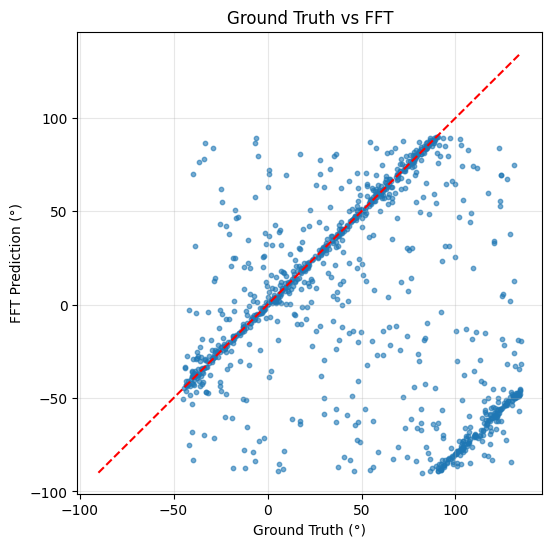

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(GT_angles, FFT_angles, s=10, alpha=0.6)

mn = min(GT_angles.min(), FFT_angles.min())
mx = max(GT_angles.max(), FFT_angles.max())

plt.plot([mn,mx],[mn,mx],'r--')
plt.xlabel("Ground Truth (°)")
plt.ylabel("FFT Prediction (°)")
plt.title("Ground Truth vs FFT")
plt.grid(alpha=0.3)
plt.show()

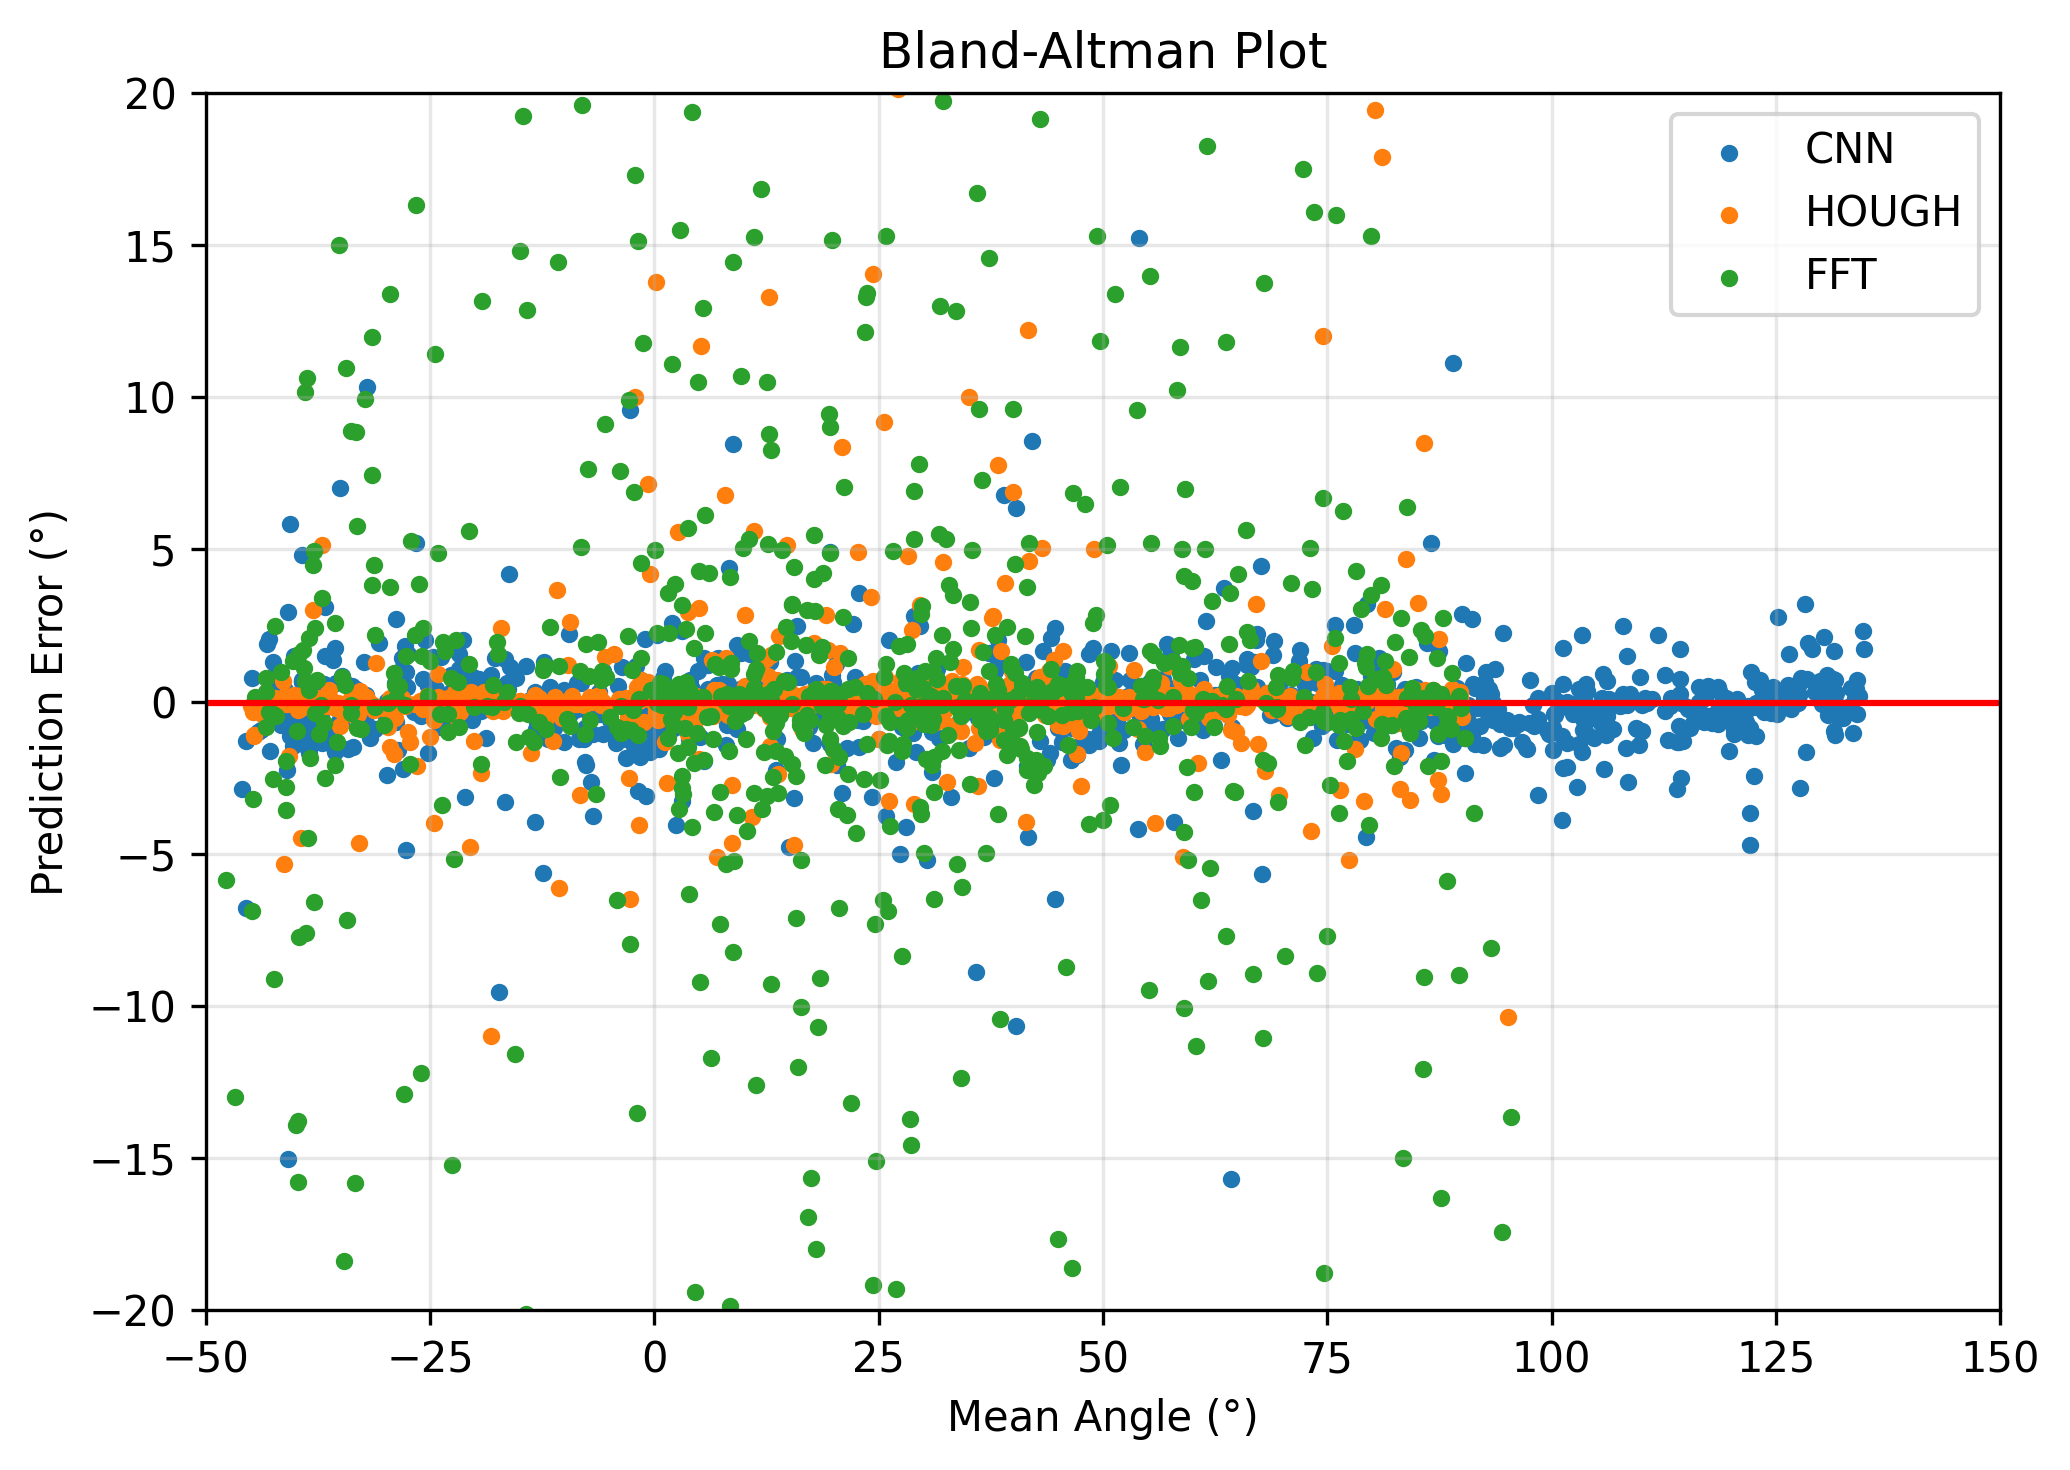

In [19]:
mean_CNN = (GT_angles + CNN_angles)/2
diff_CNN = err_CNN     
mean_Hough = (GT_angles + HOUGH_angles)/2
diff_Hough = err_Hough
mean_FFT = (GT_angles + FFT_angles)/2
diff_FFT = err_FFT              
plt.figure(figsize=(7, 5), dpi=300)
plt.scatter(mean_CNN, diff_CNN, s=10)
plt.scatter(mean_Hough, diff_Hough, s=10)
plt.scatter(mean_FFT, diff_FFT, s=10)

m = np.mean(diff_FFT)
sd = np.std(diff_FFT)

plt.axhline(m, color='red')
plt.axhline(m+1.96*sd, color='green', linestyle='--')
plt.axhline(m-1.96*sd, color='green', linestyle='--')
plt.ylim(-20, 20)
plt.xlim(-50, 150)
plt.xlabel("Mean Angle (°)")
plt.ylabel("Prediction Error (°)")
plt.title("Bland-Altman Plot")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend(["CNN", "HOUGH", "FFT"])
plt.savefig("bland_altman_plot.pdf", bbox_inches="tight")
plt.show()

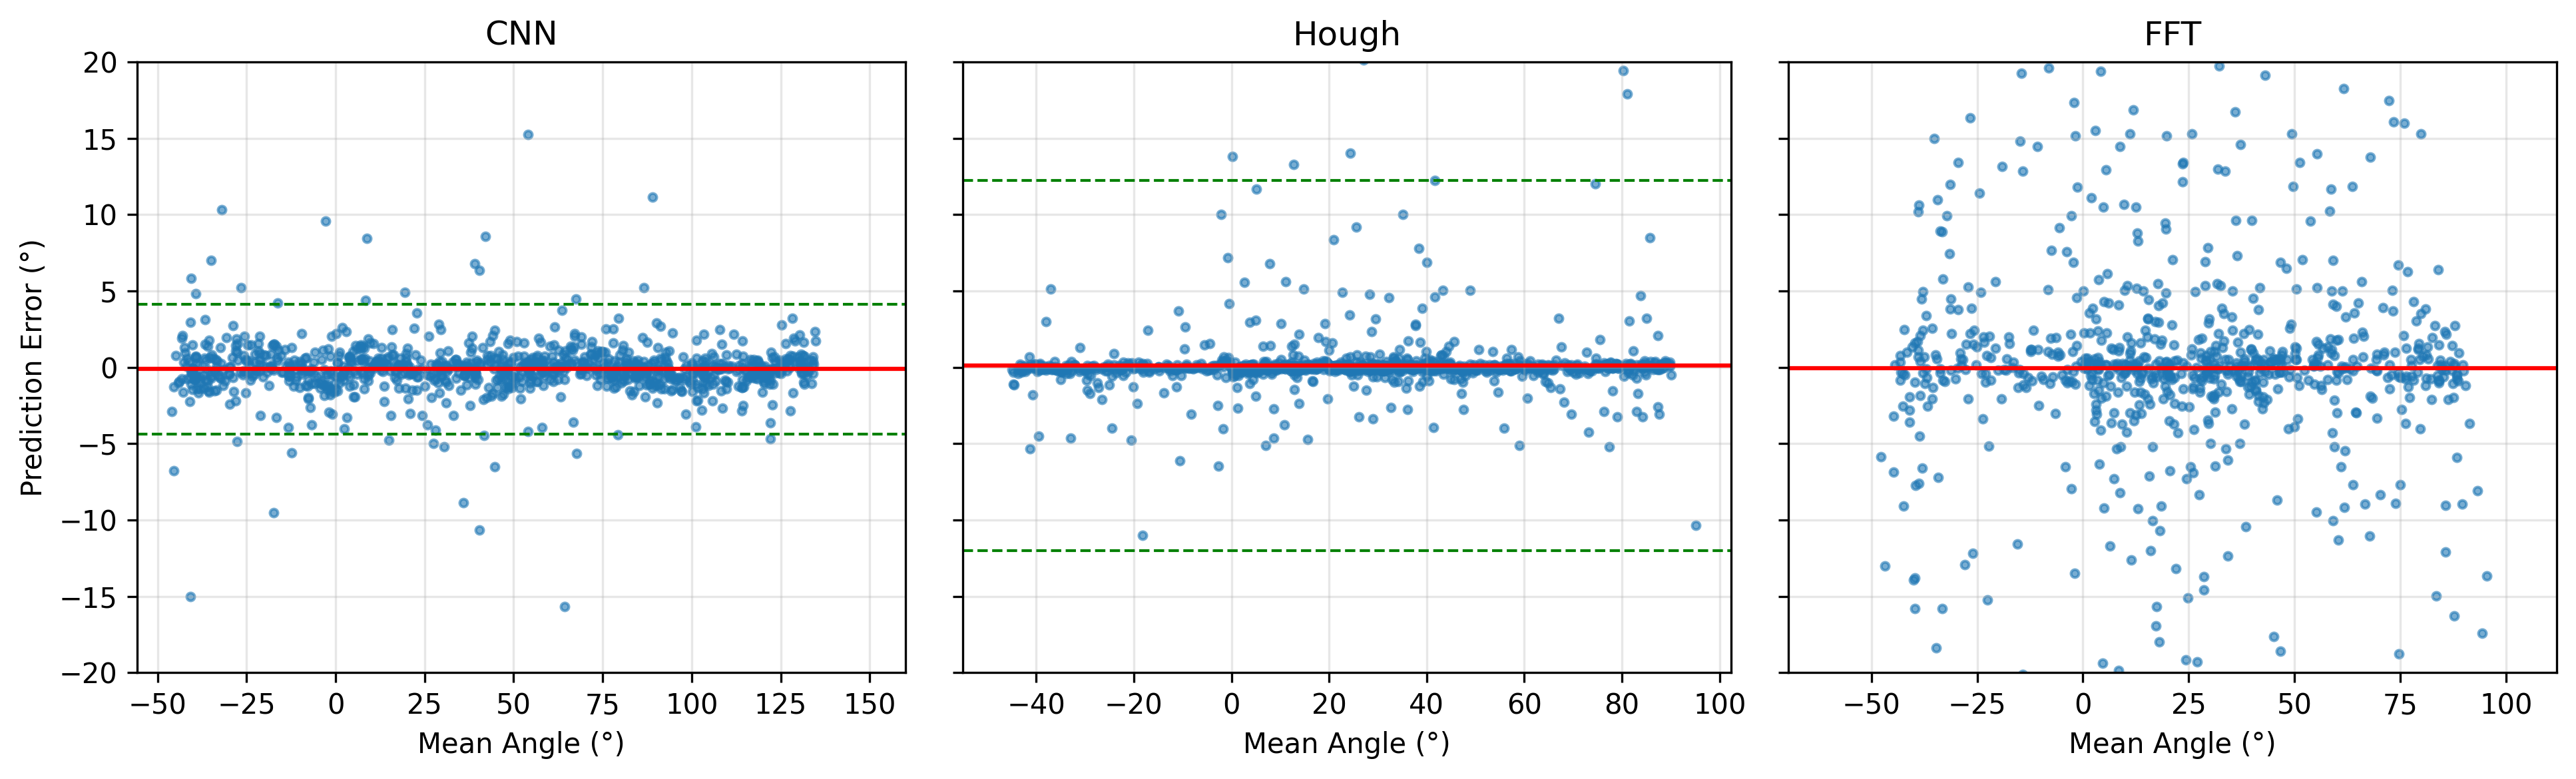

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13,4), dpi=300, sharey=True)

methods = [
    ("CNN", mean_CNN, diff_CNN),
    ("Hough", mean_Hough, diff_Hough),
    ("FFT", mean_FFT, diff_FFT),
]

for ax, (name, mean, diff) in zip(axes, methods):

    ax.scatter(mean, diff, s=8, alpha=0.6)

    bias = np.mean(diff)
    sd = np.std(diff)

    ax.axhline(bias, color='red', lw=1.5, label='Bias')
    ax.axhline(bias + 1.96*sd, color='green', ls='--', lw=1)
    ax.axhline(bias - 1.96*sd, color='green', ls='--', lw=1)

    ax.set_title(name)
    ax.set_xlabel("Mean Angle (°)")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Prediction Error (°)")
axes[0].set_ylim(-20,20)

plt.tight_layout()
plt.savefig("bland_altman_plot_all.pdf", bbox_inches="tight")

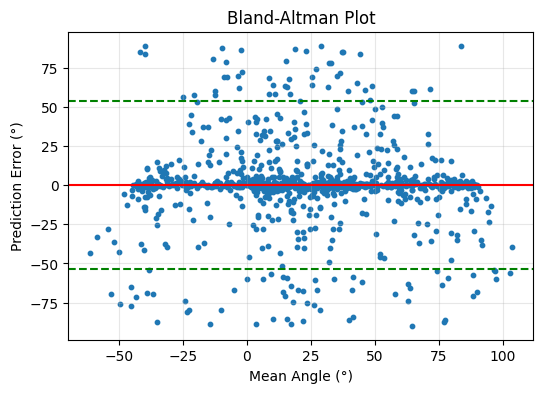

In [22]:
mean = (GT_angles + FFT_angles)/2
diff = err_FFT      

plt.figure(figsize=(6,4))
plt.scatter(mean, diff, s=10)

m = np.mean(diff)
sd = np.std(diff)

plt.axhline(m, color='red')
plt.axhline(m+1.96*sd, color='green', linestyle='--')
plt.axhline(m-1.96*sd, color='green', linestyle='--')

plt.xlabel("Mean Angle (°)")
plt.ylabel("Prediction Error (°)")
plt.title("Bland-Altman Plot")
plt.grid(alpha=0.3)
plt.show()

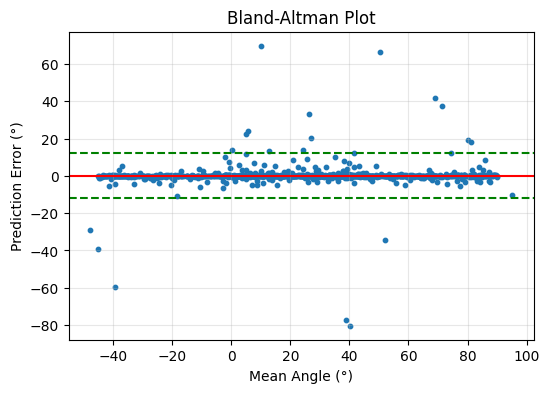

In [23]:
mean = (GT_angles + HOUGH_angles)/2
diff = err_Hough     

plt.figure(figsize=(6,4))
plt.scatter(mean, diff, s=10)

m = np.mean(diff)
sd = np.std(diff)

plt.axhline(m, color='red')
plt.axhline(m+1.96*sd, color='green', linestyle='--')
plt.axhline(m-1.96*sd, color='green', linestyle='--')

plt.xlabel("Mean Angle (°)")
plt.ylabel("Prediction Error (°)")
plt.title("Bland-Altman Plot")
plt.grid(alpha=0.3)
plt.show()

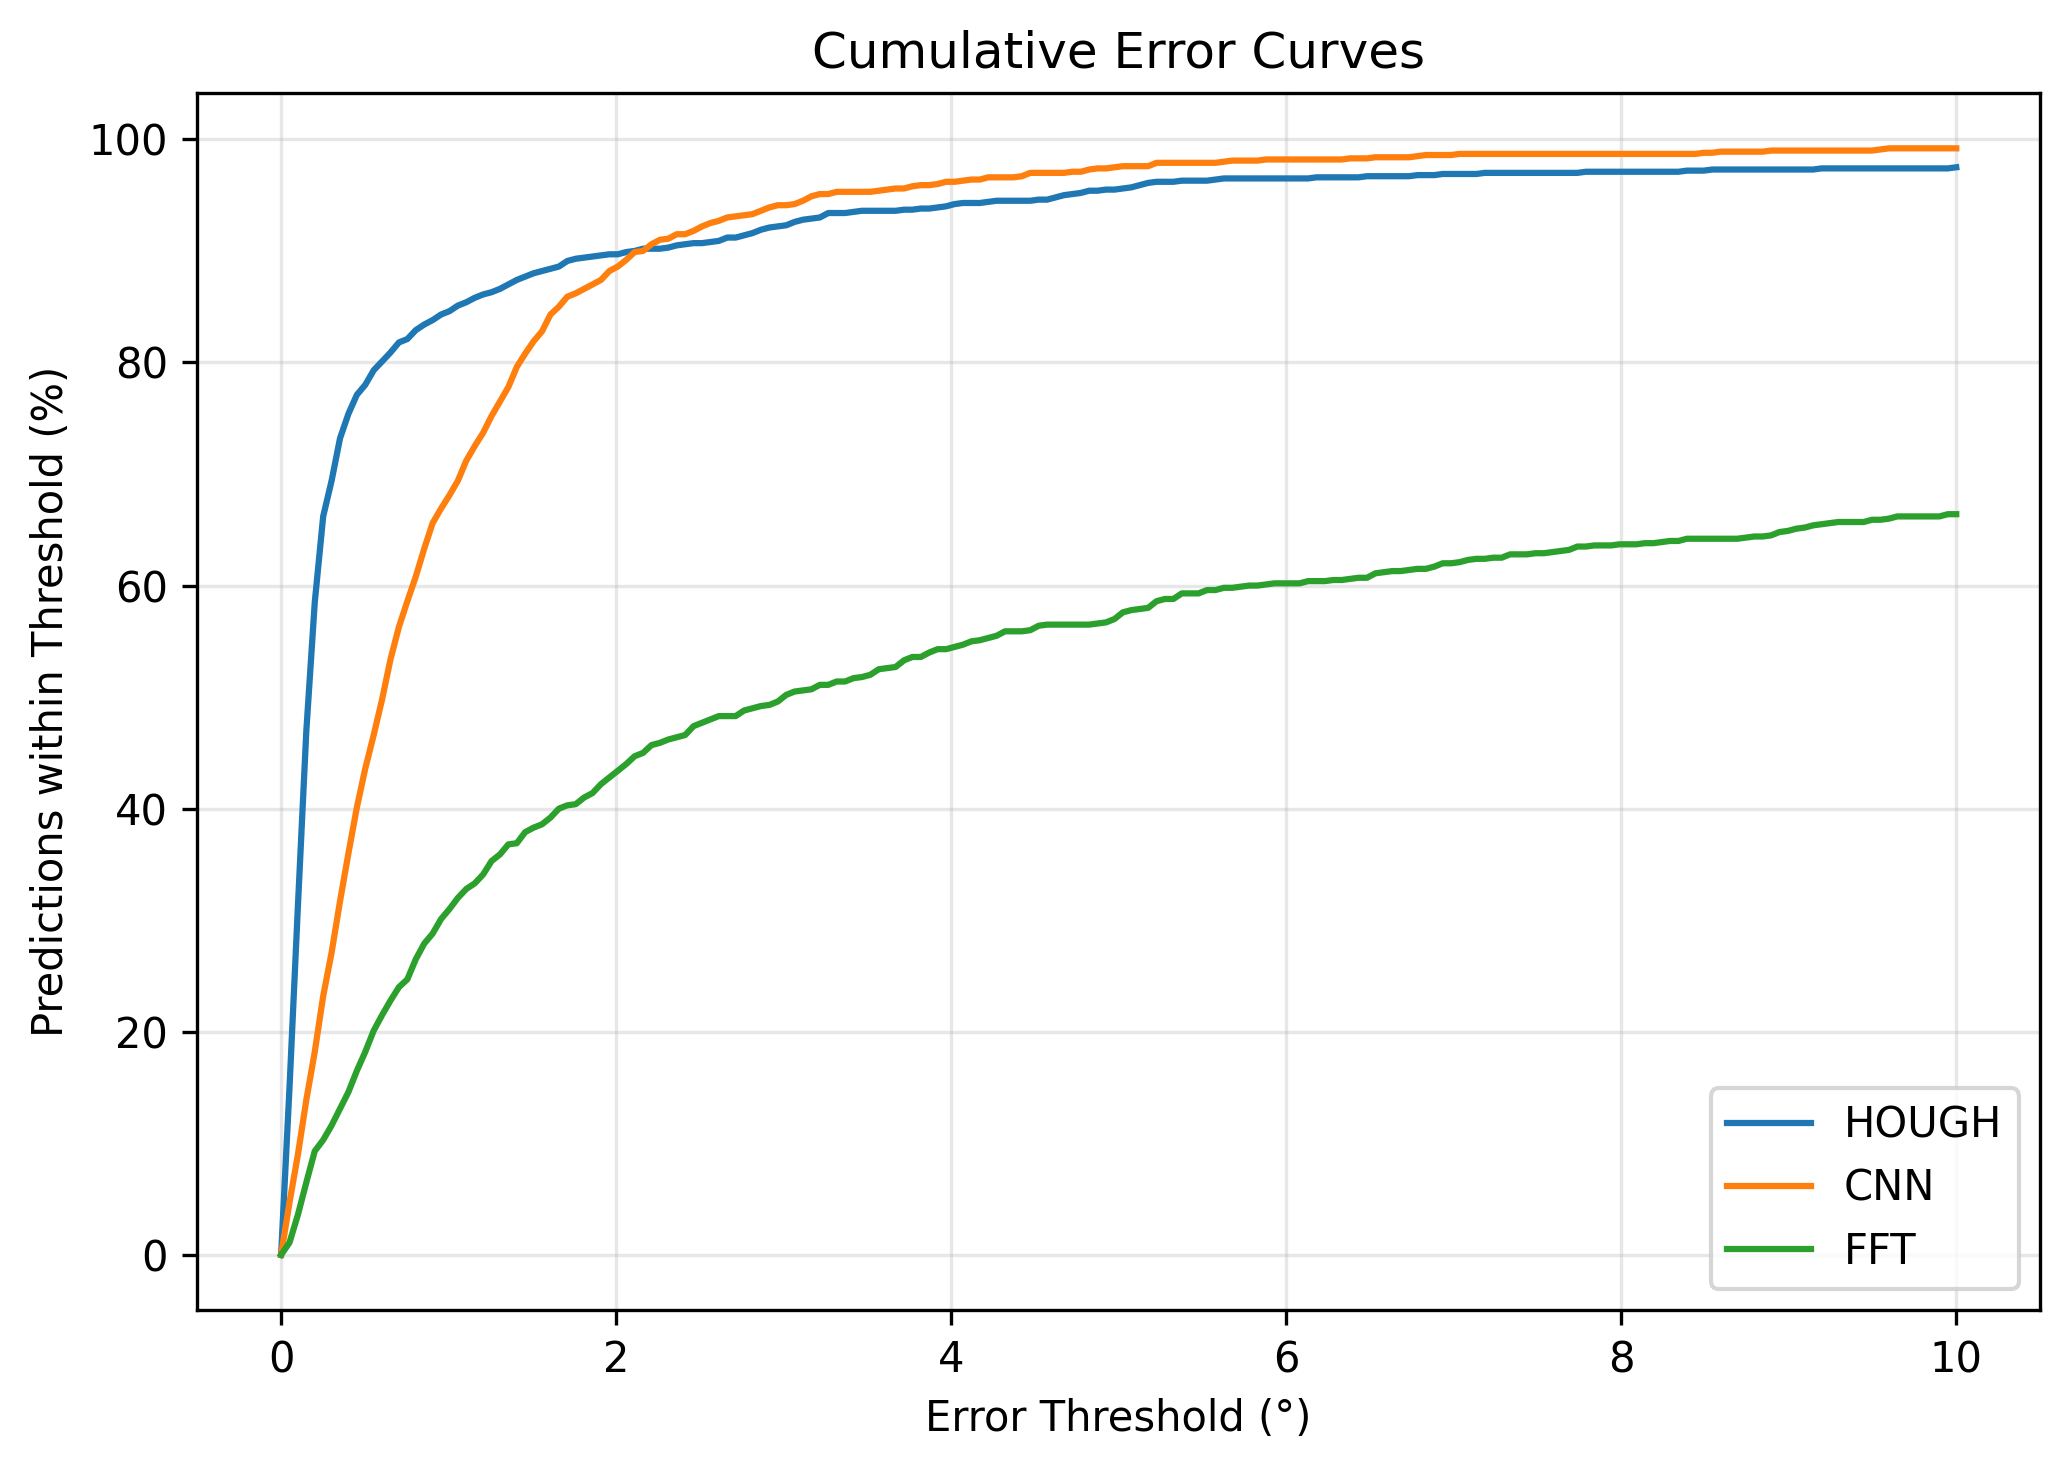

In [22]:
thresholds = np.linspace(0,10,200)

accuracy_Hough = [
    np.mean(np.abs(err_Hough) <= t)*100
    for t in thresholds
]
accuracy_CNN = [
    np.mean(np.abs(err_CNN) <= t)*100
    for t in thresholds
]
accuracy_FFT = [
    np.mean(np.abs(err_FFT) <= t)*100
    for t in thresholds
]
plt.figure(figsize=(7, 5), dpi=300)
plt.plot(thresholds, accuracy_Hough, label="HOUGH")
plt.plot(thresholds, accuracy_CNN, label="CNN")
plt.plot(thresholds, accuracy_FFT, label="FFT")

plt.xlabel("Error Threshold (°)")
plt.ylabel("Predictions within Threshold (%)")
plt.title("Cumulative Error Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cumulative_error_curves.png", dpi=300)
plt.show()

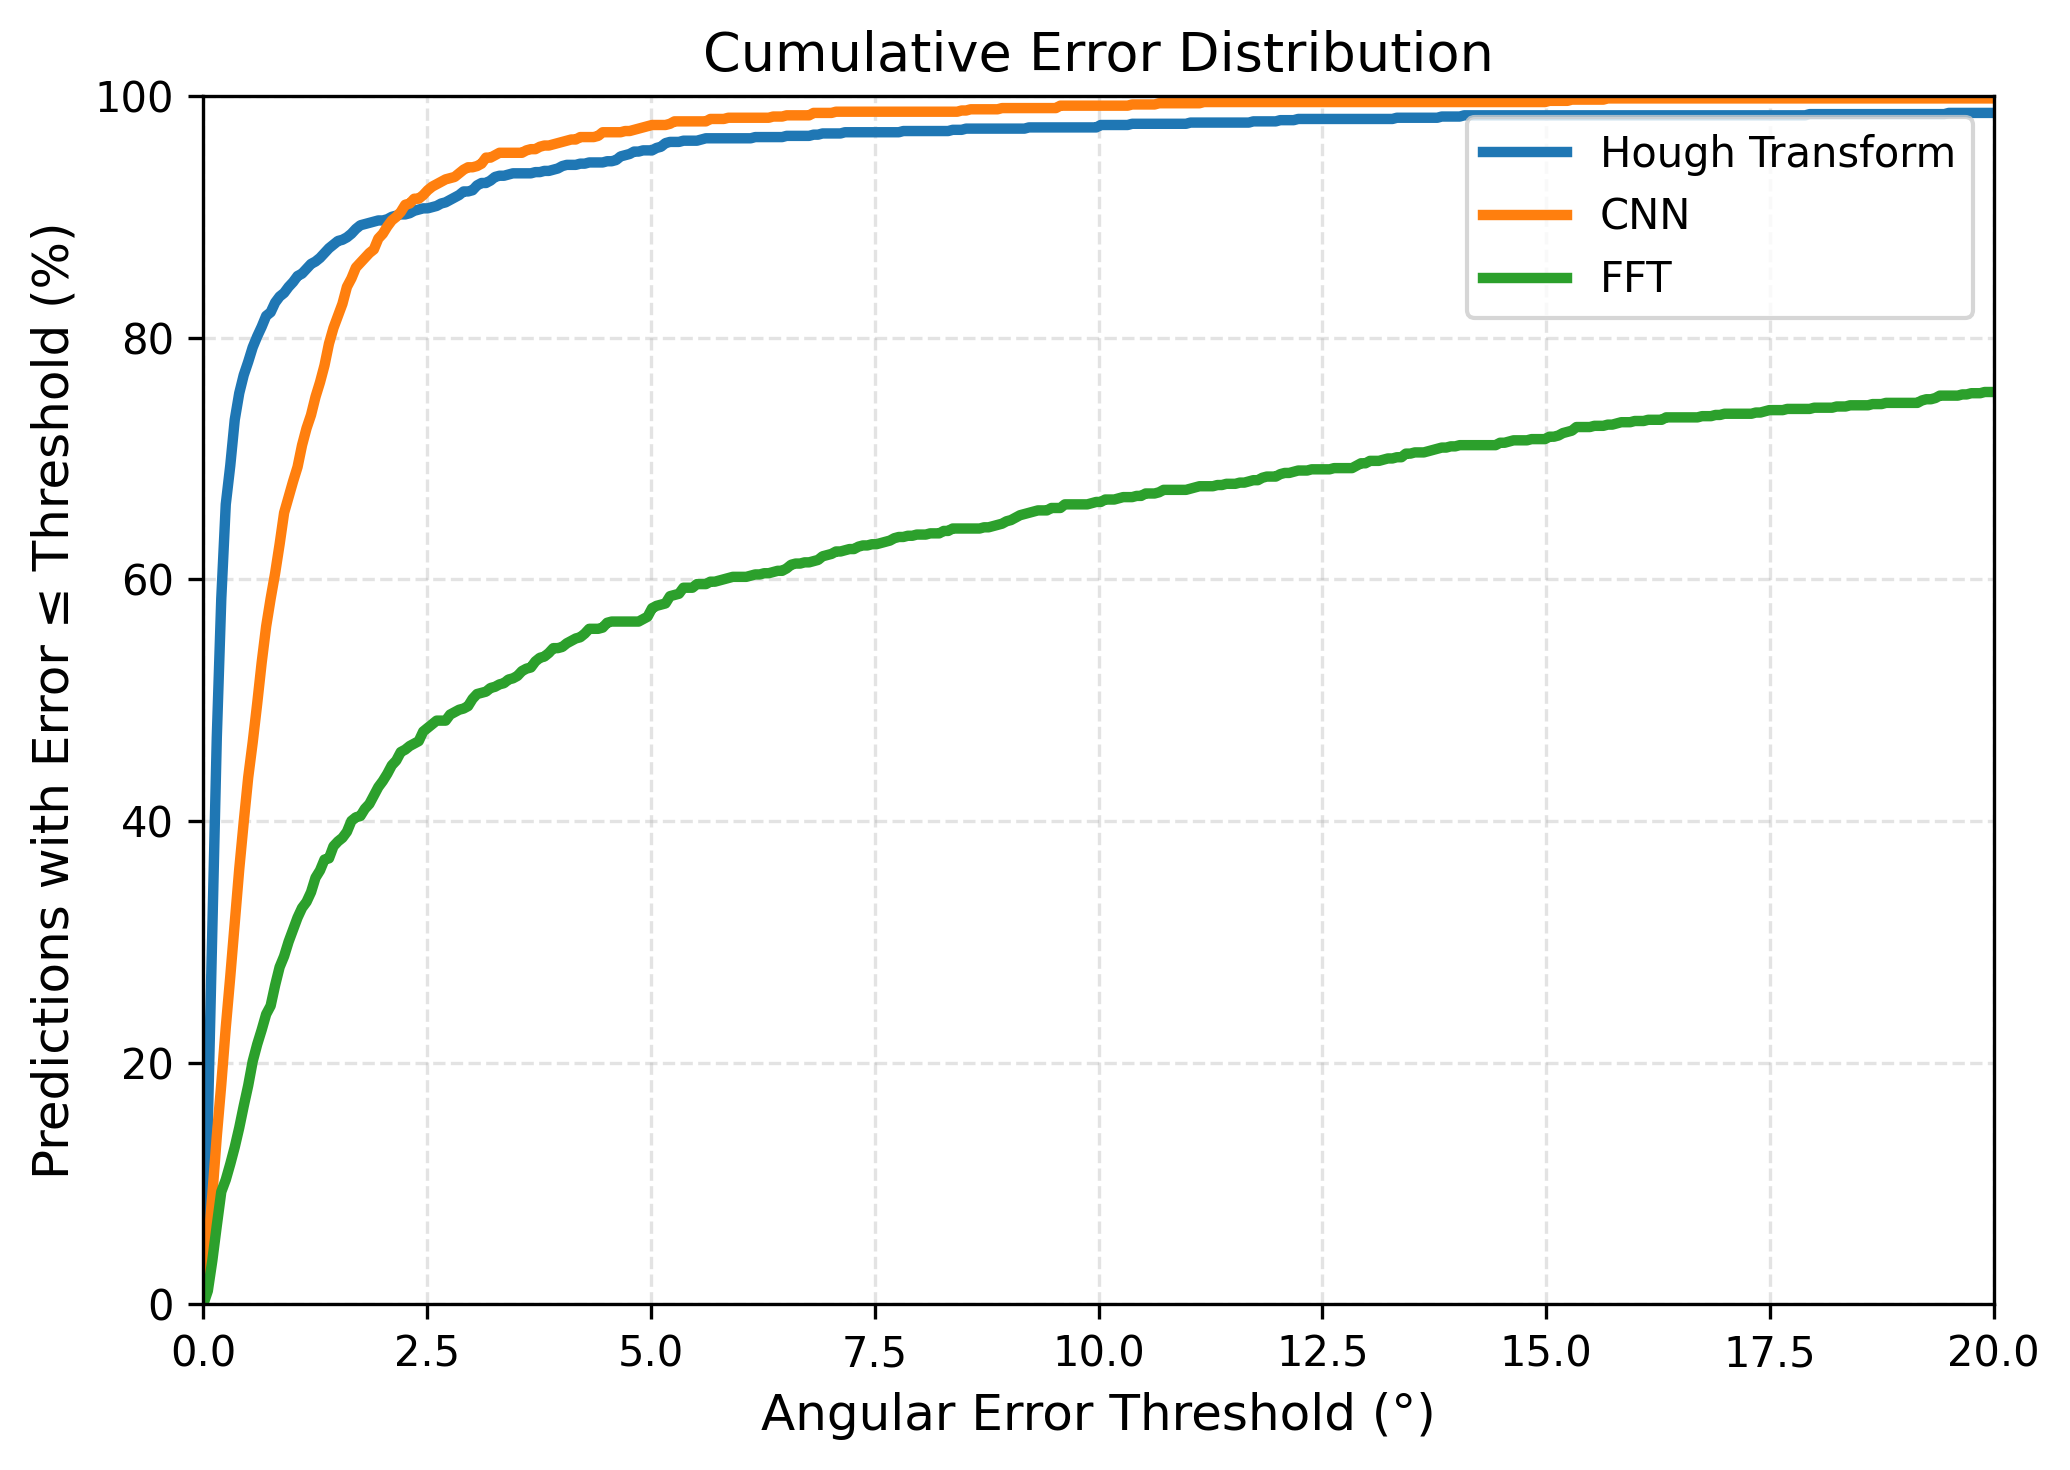

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Cumulative Error Curves
# ---------------------------------------------------------

thresholds = np.linspace(0, 20, 400)   # Extend to 20°

accuracy_Hough = [
    np.mean(np.abs(err_Hough) <= t) * 100
    for t in thresholds
]

accuracy_CNN = [
    np.mean(np.abs(err_CNN) <= t) * 100
    for t in thresholds
]

accuracy_FFT = [
    np.mean(np.abs(err_FFT) <= t) * 100
    for t in thresholds
]

plt.figure(figsize=(7, 5), dpi=300)

plt.plot(
    thresholds,
    accuracy_Hough,
    linewidth=2.5,
    label="Hough Transform"
)

plt.plot(
    thresholds,
    accuracy_CNN,
    linewidth=2.5,
    label="CNN"
)

plt.plot(
    thresholds,
    accuracy_FFT,
    linewidth=2.5,
    label="FFT"
)

plt.xlim(0, 20)
plt.ylim(0, 100)

plt.xlabel("Angular Error Threshold (°)", fontsize=12)
plt.ylabel("Predictions with Error ≤ Threshold (%)", fontsize=12)
plt.title("Cumulative Error Distribution", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig("cumulative_error_curve.pdf", bbox_inches="tight")
plt.savefig("cumulative_error_curve.svg", bbox_inches="tight")
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_26348\355610152.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


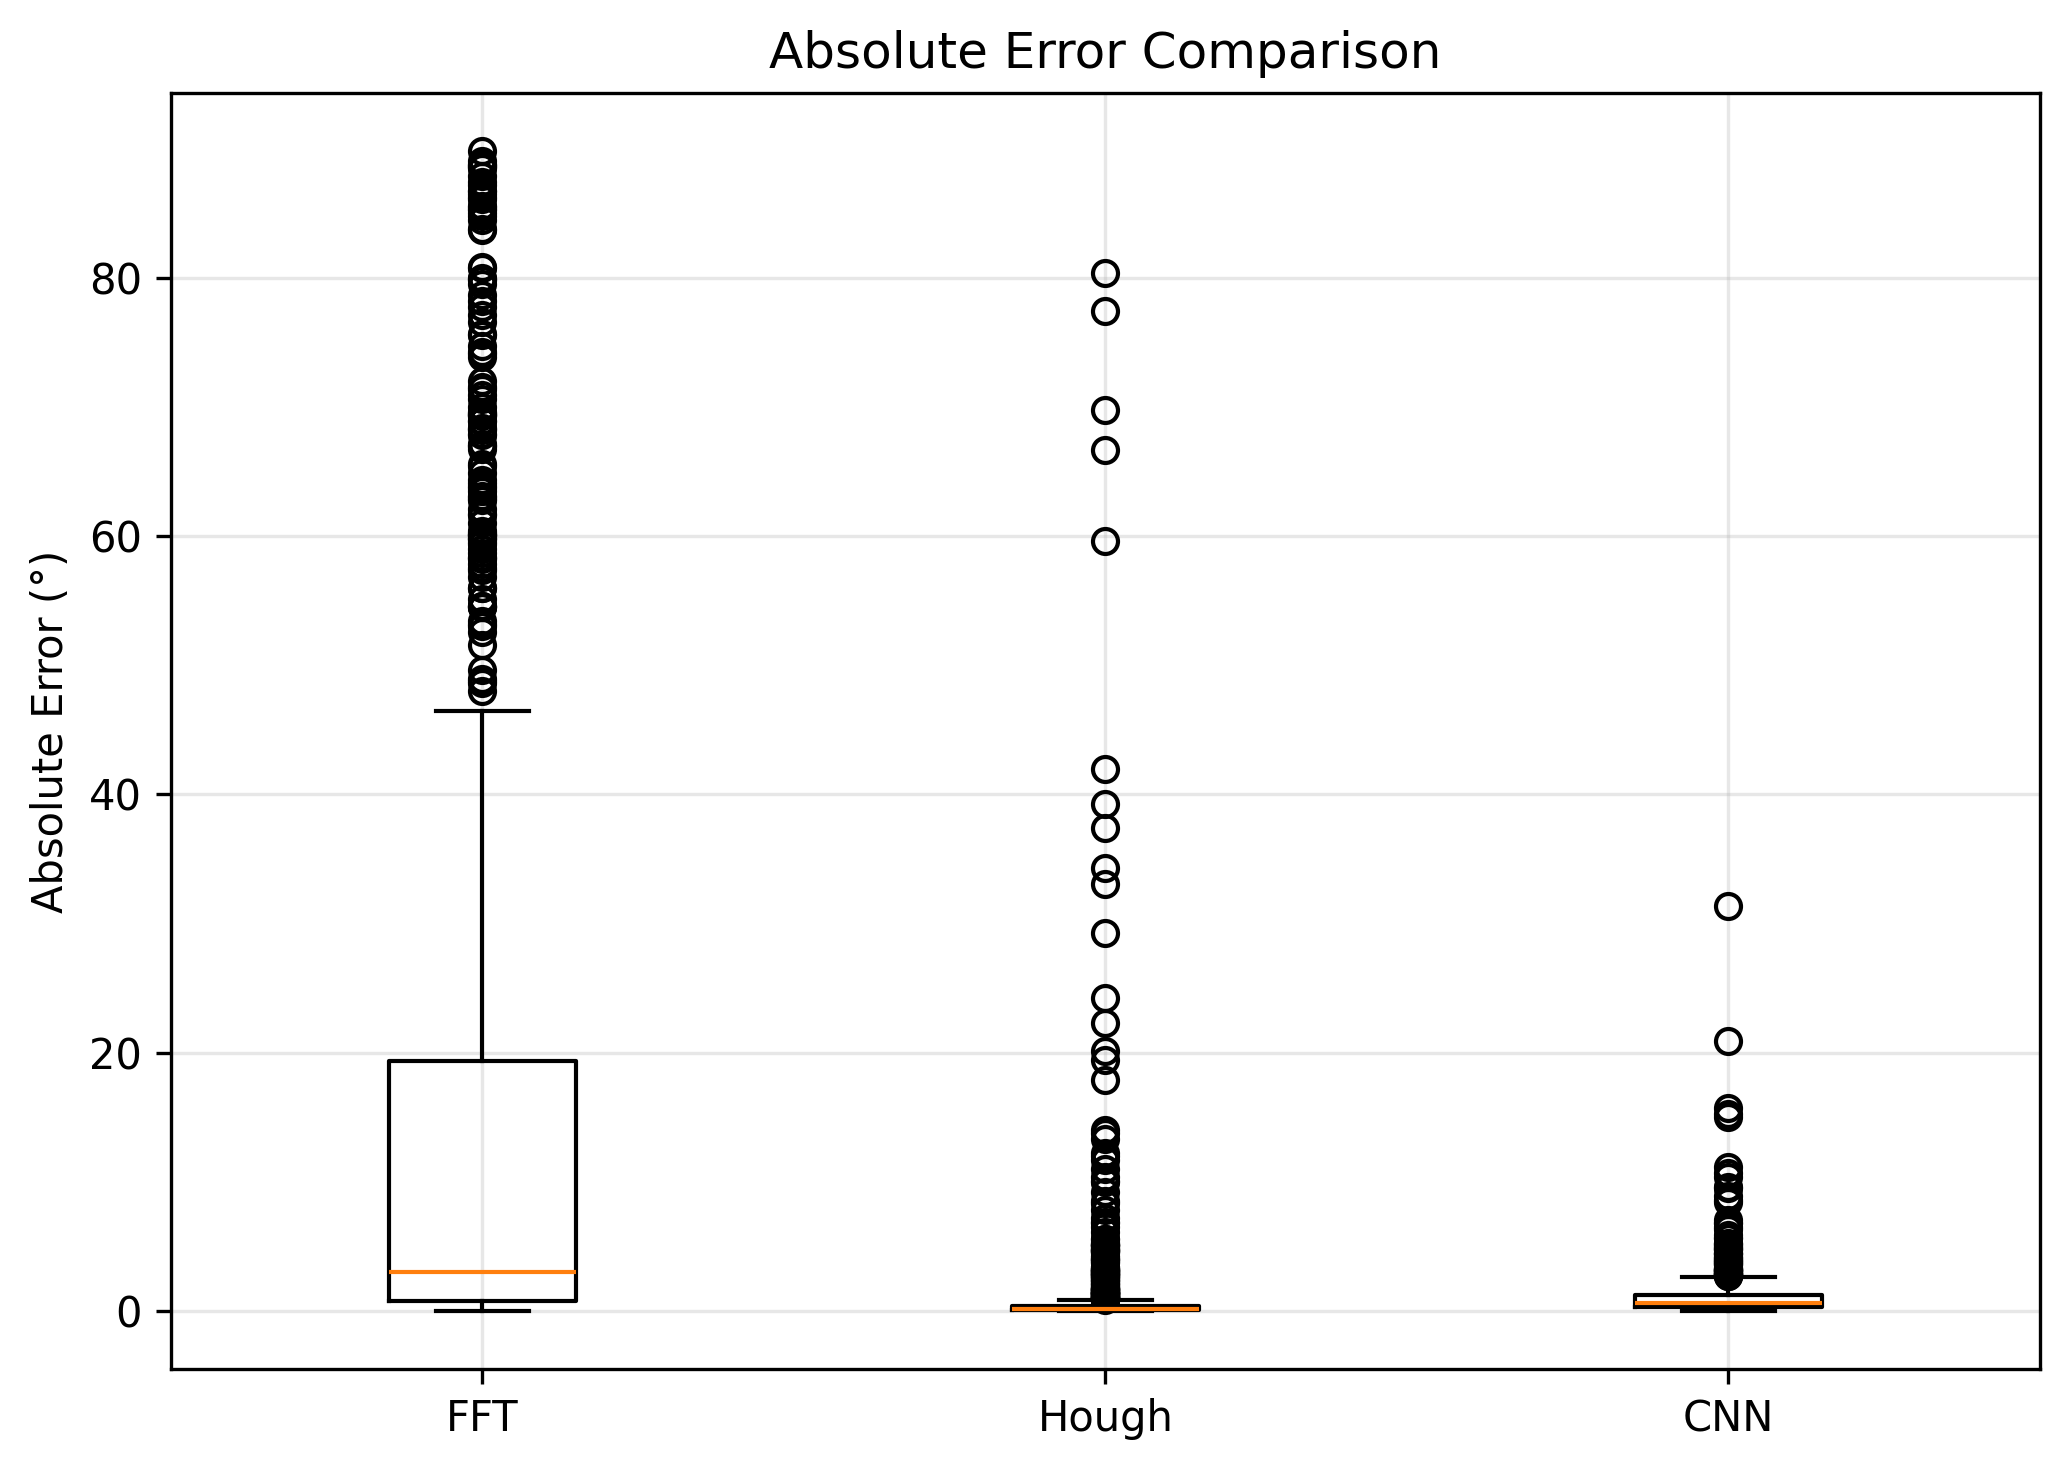

In [23]:
plt.figure(figsize=(7, 5), dpi=300)
plt.boxplot([
    np.abs(err_FFT),
    np.abs(err_Hough),
    np.abs(err_CNN)
], labels=["FFT","Hough","CNN"])

plt.ylabel("Absolute Error (°)")
plt.title("Absolute Error Comparison")
plt.grid(alpha=0.3) 
plt.tight_layout()
plt.savefig("absolute_error_comparison.pdf", bbox_inches="tight")
plt.show()

In [26]:
import pandas as pd
import numpy as np

FFT_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_corrected_FFT2\images\angles.csv"
HOUGH_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_corrected_hough2\images\angles.csv"
GT_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\labels.csv"
CNN_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_cnn\angles.csv"

# Read CSVs
fft = pd.read_csv(FFT_ROOT)
hough = pd.read_csv(HOUGH_ROOT)
cnn = pd.read_csv(CNN_ROOT)
gt = pd.read_csv(GT_ROOT)

print(gt.columns)
print(fft.columns)
print(hough.columns)
print(cnn.columns)

Index(['filename', 'angle_deg', 'n_fringes'], dtype='object')
Index(['image', 'fringe_angle_deg', 'rotation_deg'], dtype='object')
Index(['image', 'fringe_angle_deg', 'vertical_error_deg', 'rotation_deg'], dtype='object')
Index(['image', 'original_image', 'predicted_angle'], dtype='object')


In [27]:
# Ground truth
gt = gt.rename(columns={
    "filename": "image",
    "angle_deg": "GT"
})

# FFT
fft = fft.rename(columns={
    "fringe_angle_deg": "FFT"
})

# Hough
hough = hough.rename(columns={
    "fringe_angle_deg": "Hough"
})

# CNN
cnn = cnn.rename(columns={
    "predicted_angle": "CNN"
})

In [28]:
cnn["image"] = cnn["image"].str.replace(
    "_aligned.png",
    ".png",
    regex=False
)

In [29]:
df = (
    gt[["image", "GT", "n_fringes"]]
    .merge(fft[["image", "FFT"]], on="image")
    .merge(hough[["image", "Hough"]], on="image")
    .merge(cnn[["image", "CNN"]], on="image")
)

In [31]:
df.describe()

,GT,n_fringes,FFT,Hough,CNN
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.792901,17.613607,-1.317917,-2.411136,45.964967
std,51.763111,10.489619,51.276557,50.555764,52.488934
min,-44.847784,3.019851,-89.719322,-89.972659,-138.916672
25%,2.589182,8.049395,-43.551293,-44.309079,1.744713
50%,48.310518,16.274849,-1.860337,-2.863145,47.898323
75%,90.115735,24.269099,41.595655,40.514882,89.669640
max,134.926730,39.734001,89.815186,89.799150,165.862244


In [32]:
import numpy as np

def angular_error(pred, gt):
    return (pred - gt + 90) % 180 - 90

df["FFT_Error"] = angular_error(df["FFT"], df["GT"])
df["Hough_Error"] = angular_error(df["Hough"], df["GT"])
df["CNN_Error"] = angular_error(df["CNN"], df["GT"])

In [33]:
print(df.head())

            image         GT  n_fringes        FFT      Hough        CNN  \
0  img_000000.png  84.499060  35.157888  -5.342614  -8.382112  82.908264   
1  img_000001.png  54.947243  33.988348 -33.527731 -35.056203  55.603302   
2  img_000002.png -44.076990   6.799576  56.567886  44.817946 -42.171204   
3  img_000003.png  39.428015   3.686197  77.842099 -45.959922  39.886765   
4  img_000004.png  22.459130   5.097633 -39.157004 -64.114938  19.440353   

   FFT_Error  Hough_Error  CNN_Error  
0 -89.841673    87.118828  -1.590795  
1 -88.474974    89.996554   0.656059  
2 -79.355124    88.894937   1.905787  
3  38.414084   -85.387938   0.458749  
4 -61.616134   -86.574068  -3.018776  


In [34]:
print("FFT MAE   :", np.mean(np.abs(df["FFT_Error"])))
print("Hough MAE :", np.mean(np.abs(df["Hough_Error"])))
print("CNN MAE   :", np.mean(np.abs(df["CNN_Error"])))

FFT MAE   : 75.02682543607203
Hough MAE : 88.6676230659631
CNN MAE   : 1.0762603707155232


In [10]:
df = pd.DataFrame({
    "image": GT_df["filename"],
    "GT": GT_angles,
    "FFT": FFT_angles,
    "Hough": HOUGH_angles,
    "CNN": CNN_angles,
    "n_fringes": GT_df["n_fringes"]
})

df["FFT_Error"] = angular_error(df["FFT"], df["GT"])
df["Hough_Error"] = angular_error(df["Hough"], df["GT"])
df["CNN_Error"] = angular_error(df["CNN"], df["GT"])

In [11]:
df["FFT_AbsErr"] = np.abs(df["FFT_Error"])
df["Hough_AbsErr"] = np.abs(df["Hough_Error"])
df["CNN_AbsErr"] = np.abs(df["CNN_Error"])

In [12]:
df["Overall_Error"] = df[
    ["FFT_AbsErr", "Hough_AbsErr", "CNN_AbsErr"]
].max(axis=1)

In [13]:
best_overall = df.nsmallest(10, "Overall_Error")

worst_fft = df.nlargest(10, "FFT_AbsErr")

worst_hough = df.nlargest(10, "Hough_AbsErr")

worst_cnn = df.nlargest(10, "CNN_AbsErr")

In [14]:
cols = [
    "image",
    "GT",
    "FFT", "FFT_AbsErr",
    "Hough", "Hough_AbsErr",
    "CNN", "CNN_AbsErr",
    "n_fringes"
]

print("Best Overall")
print(best_overall[cols])

print("\nWorst FFT")
print(worst_fft[cols])

print("\nWorst Hough")
print(worst_hough[cols])

print("\nWorst CNN")
print(worst_cnn[cols])

Best Overall
              image          GT        FFT  FFT_AbsErr      Hough  \
421  img_000421.png   62.099151  62.129939    0.030788  62.084551   
937  img_000937.png   36.344490  36.401728    0.057238  36.301474   
446  img_000446.png   61.154401  61.225658    0.071257  61.118278   
777  img_000777.png   10.778797  10.837996    0.059199  10.773412   
646  img_000646.png   31.856417  31.735382    0.121035  31.908904   
935  img_000935.png   35.807540  35.675019    0.132521  35.844529   
322  img_000322.png   18.707941  18.568900    0.139041  18.780066   
359  img_000359.png   99.938677 -79.915004    0.146319 -80.090171   
874  img_000874.png   28.638522  28.526181    0.112340  28.804431   
991  img_000991.png  110.184505 -69.630532    0.184963 -69.972261   

     Hough_AbsErr         CNN  CNN_AbsErr  n_fringes  
421      0.014600   62.145523    0.046372  22.308582  
937      0.043016   36.383667    0.039177  28.809068  
446      0.036122   61.101944    0.052457  21.501700  
777    

In [15]:
used = set()

def pick_unique(df, n=3):
    rows = []
    for _, row in df.iterrows():
        if row["image"] not in used:
            rows.append(row)
            used.add(row["image"])
        if len(rows) == n:
            break
    return pd.DataFrame(rows)

best = pick_unique(best_overall)
fft_fail = pick_unique(worst_fft)
hough_fail = pick_unique(worst_hough)
cnn_fail = pick_unique(worst_cnn)

In [16]:
print(best["image"])
print(fft_fail["image"])
print(hough_fail["image"])
print(cnn_fail["image"])

421    img_000421.png
937    img_000937.png
446    img_000446.png
Name: image, dtype: object
751    img_000751.png
934    img_000934.png
643    img_000643.png
Name: image, dtype: object
659    img_000659.png
293    img_000293.png
56     img_000056.png
Name: image, dtype: object
404    img_000404.png
158    img_000158.png
683    img_000683.png
Name: image, dtype: object


In [17]:
used = set()

def pick_unique(df_in, n=3):
    rows = []

    for _, row in df_in.iterrows():

        if row["image"] in used:
            continue

        rows.append(row)
        used.add(row["image"])

        if len(rows) == n:
            break

    return pd.DataFrame(rows)


best = pick_unique(best_overall, n=3)

fft_fail = pick_unique(worst_fft, n=3)

hough_fail = pick_unique(worst_hough, n=3)

cnn_fail = pick_unique(worst_cnn, n=3)

In [18]:
best["Category"] = "Best"

fft_fail["Category"] = "FFT Failure"

hough_fail["Category"] = "Hough Failure"

cnn_fail["Category"] = "CNN Failure"

selected = pd.concat(
    [best, fft_fail, hough_fail, cnn_fail],
    ignore_index=True
)

In [19]:
cols = [
    "Category",
    "image",
    "GT",
    "FFT_AbsErr",
    "Hough_AbsErr",
    "CNN_AbsErr",
    "n_fringes"
]

print(selected[cols].to_string(index=False))

     Category          image         GT  FFT_AbsErr  Hough_AbsErr  CNN_AbsErr  n_fringes
         Best img_000421.png  62.099151    0.030788      0.014600    0.046372  22.308582
         Best img_000937.png  36.344490    0.057238      0.043016    0.039177  28.809068
         Best img_000446.png  61.154401    0.071257      0.036122    0.052457  21.501700
  FFT Failure img_000751.png 109.432030   89.807404      1.136509    0.805458   4.333458
  FFT Failure img_000934.png  74.443350   89.013287      0.578515    1.014780   8.179666
  FFT Failure img_000643.png 129.219336   88.827893      0.293982    1.663153   7.126867
Hough Failure img_000659.png  -9.621600   22.450976     80.378400    5.622052   4.196946
Hough Failure img_000293.png -12.552205   20.892854     77.447795    9.545298   3.119691
Hough Failure img_000056.png -24.775725   21.264090     69.775725   20.904161   3.377350
  CNN Failure img_000404.png 134.515264    2.112125      0.250607   31.346979  21.521696
  CNN Failure img_000

In [25]:
import pandas as pd
import numpy as np

# Copy to avoid modifying the original
plot_df = df.copy()

# Absolute errors
plot_df["FFT_MAE"] = np.abs(plot_df["FFT_Error"])
plot_df["Hough_MAE"] = np.abs(plot_df["Hough_Error"])
plot_df["CNN_MAE"] = np.abs(plot_df["CNN_Error"])

# Create bins (adjust the number if needed)
plot_df["FringeBin"] = pd.qcut(
    plot_df["n_fringes"],
    q=10,
    duplicates="drop"
)

In [28]:
stats = (
    plot_df
    .groupby("FringeBin")
    .agg(
        Fringe=("n_fringes","mean"),

        FFT_mean=("FFT_MAE","mean"),
        FFT_std=("FFT_MAE","std"),

        Hough_mean=("Hough_MAE","mean"),
        Hough_std=("Hough_MAE","std"),

        CNN_mean=("CNN_MAE","mean"),
        CNN_std=("CNN_MAE","std"),
    )
)

C:\Users\admin\AppData\Local\Temp\ipykernel_11780\3252664677.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("FringeBin")


In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5), dpi=300)

plt.plot(stats["Fringe"], stats["FFT"], 'o-', label="FFT")
plt.plot(stats["Fringe"], stats["Hough"], 's-', label="Hough")
plt.plot(stats["Fringe"], stats["CNN"], '^-', label="FringeNet")

plt.xlabel("Number of Fringes")
plt.ylabel("Mean Absolute Error (°)")
plt.title("Effect of Fringe Density on Orientation Estimation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("mae_vs_fringe_density.pdf", bbox_inches="tight")
plt.show()

KeyError: 'FFT'

<Figure size 2100x1500 with 0 Axes>

In [31]:
print(stats.columns)

Index(['Fringe', 'FFT_mean', 'FFT_std', 'Hough_mean', 'Hough_std', 'CNN_mean',
       'CNN_std'],
      dtype='object')


<ErrorbarContainer object of 3 artists>

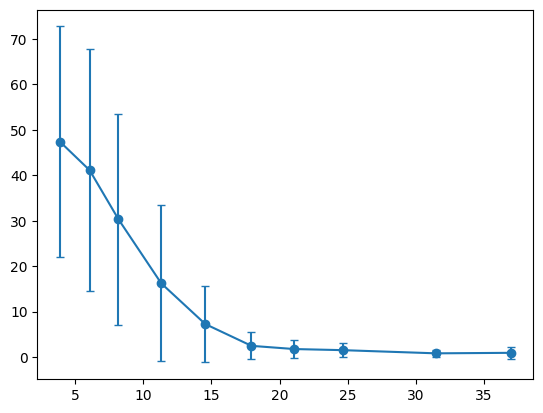

In [30]:
plt.errorbar(stats["Fringe"],
             stats["FFT_mean"],
             yerr=stats["FFT_std"],
             fmt='o-', capsize=3,
             label="FFT")

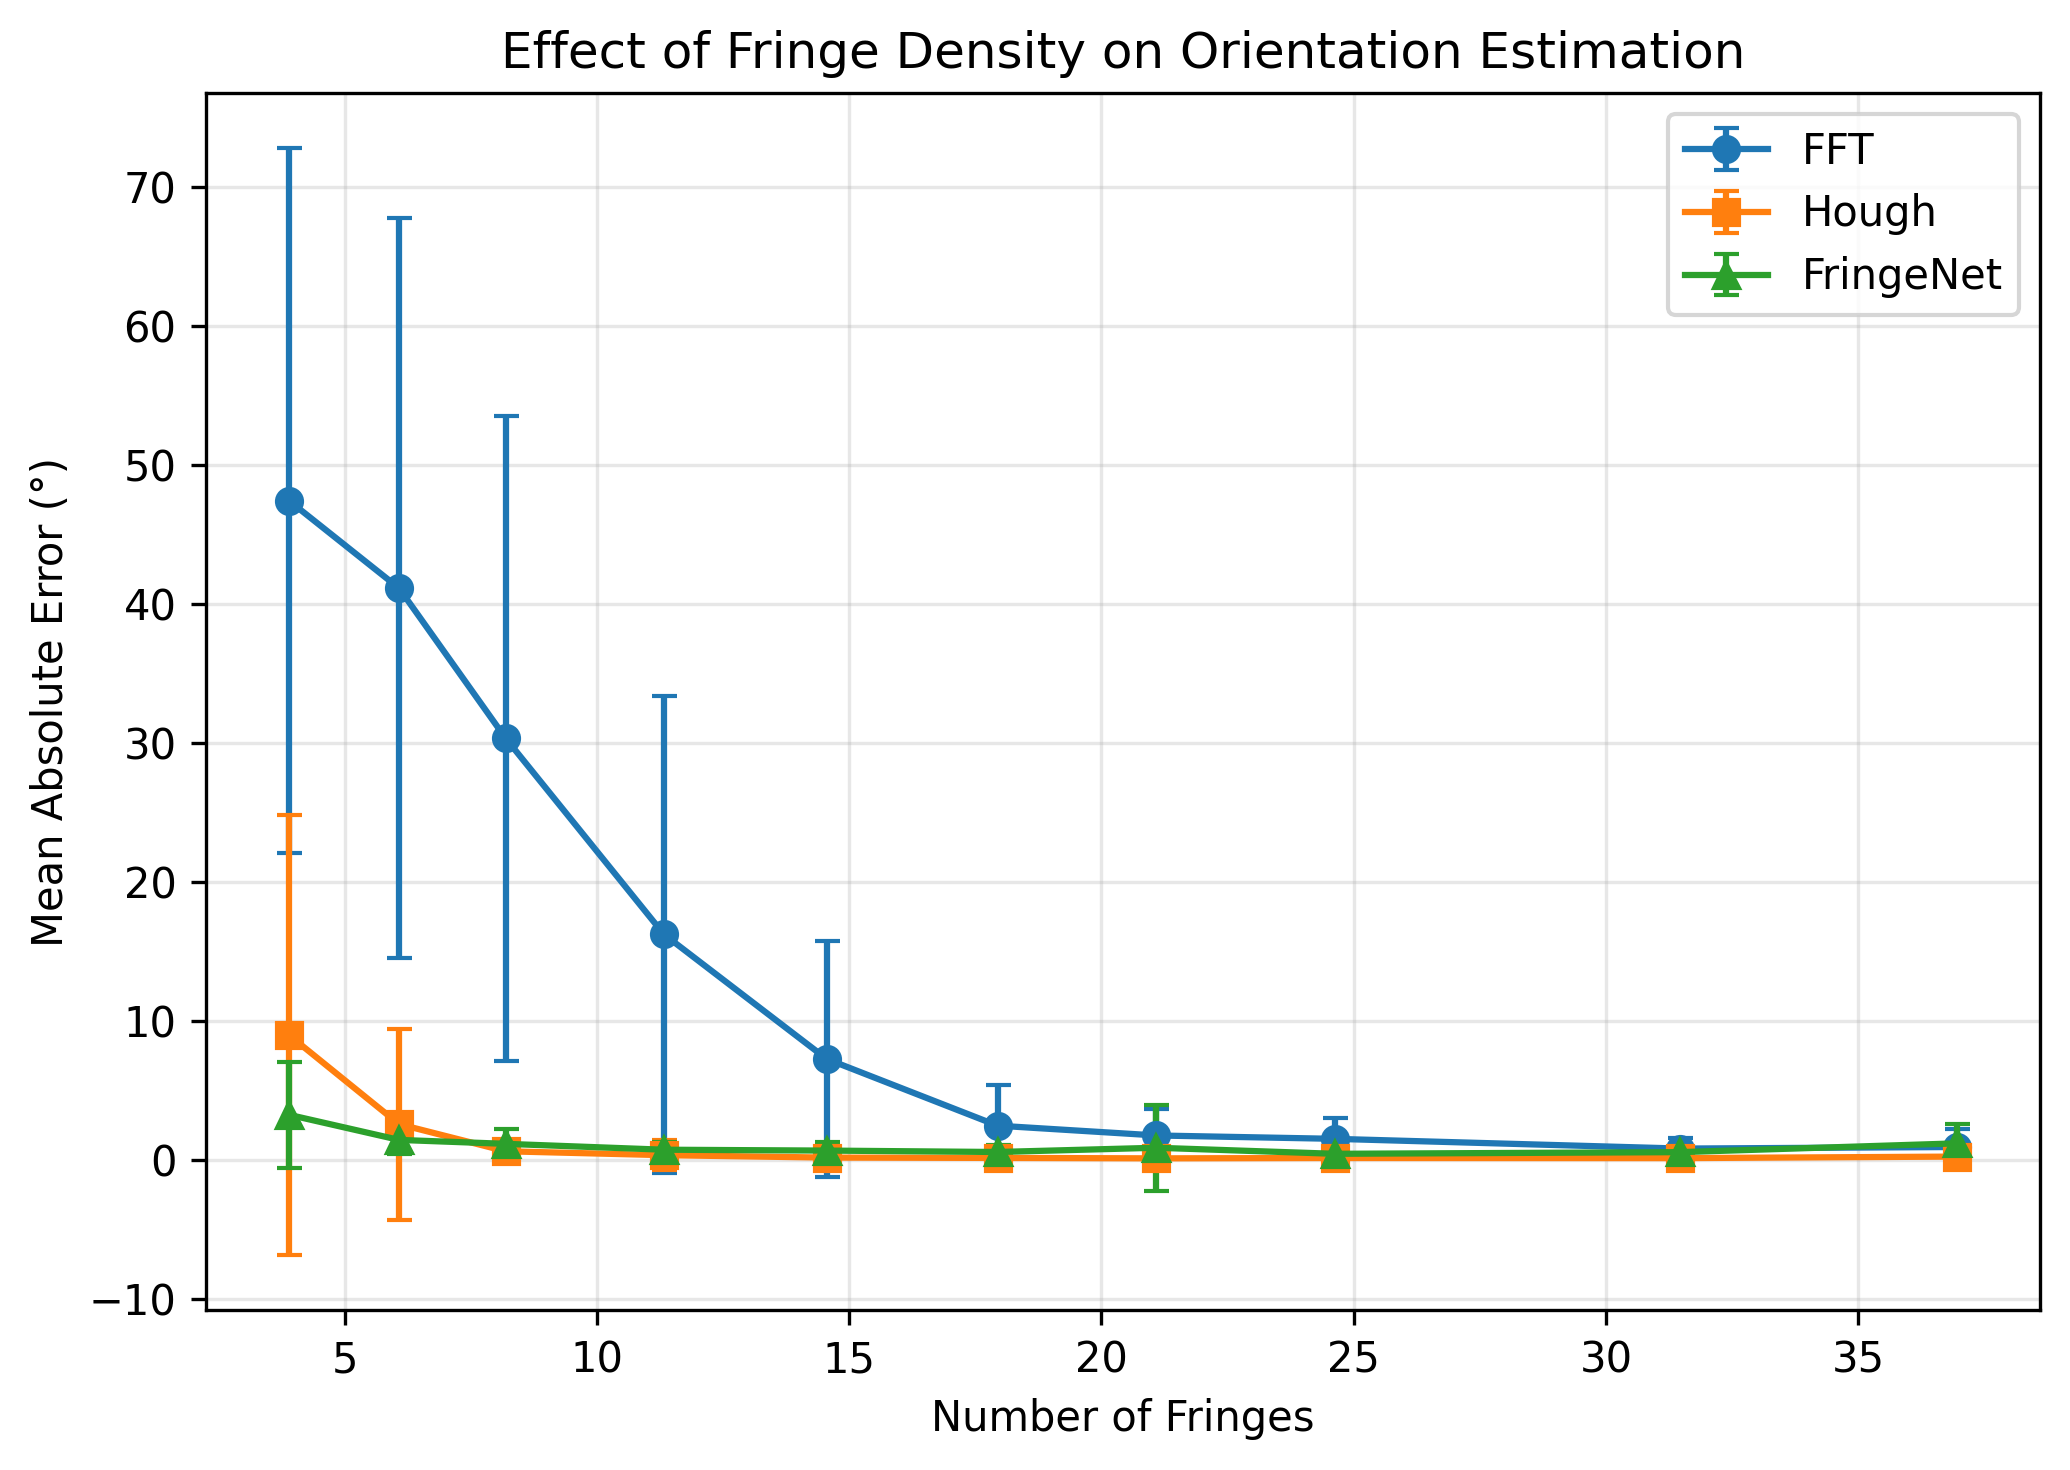

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5), dpi=300)

plt.errorbar(
    stats["Fringe"],
    stats["FFT_mean"],
    yerr=stats["FFT_std"],
    fmt='o-',
    capsize=3,
    label="FFT"
)

plt.errorbar(
    stats["Fringe"],
    stats["Hough_mean"],
    yerr=stats["Hough_std"],
    fmt='s-',
    capsize=3,
    label="Hough"
)

plt.errorbar(
    stats["Fringe"],
    stats["CNN_mean"],
    yerr=stats["CNN_std"],
    fmt='^-',
    capsize=3,
    label="FringeNet"
)

plt.xlabel("Number of Fringes")
plt.ylabel("Mean Absolute Error (°)")
plt.title("Effect of Fringe Density on Orientation Estimation")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("mae_vs_fringe_density_errorbars.pdf", dpi=300)
plt.show()

In [36]:
plot_df["FringeBin"] = pd.qcut(
    plot_df["n_fringes"],
    q=20,
    duplicates="drop"
)


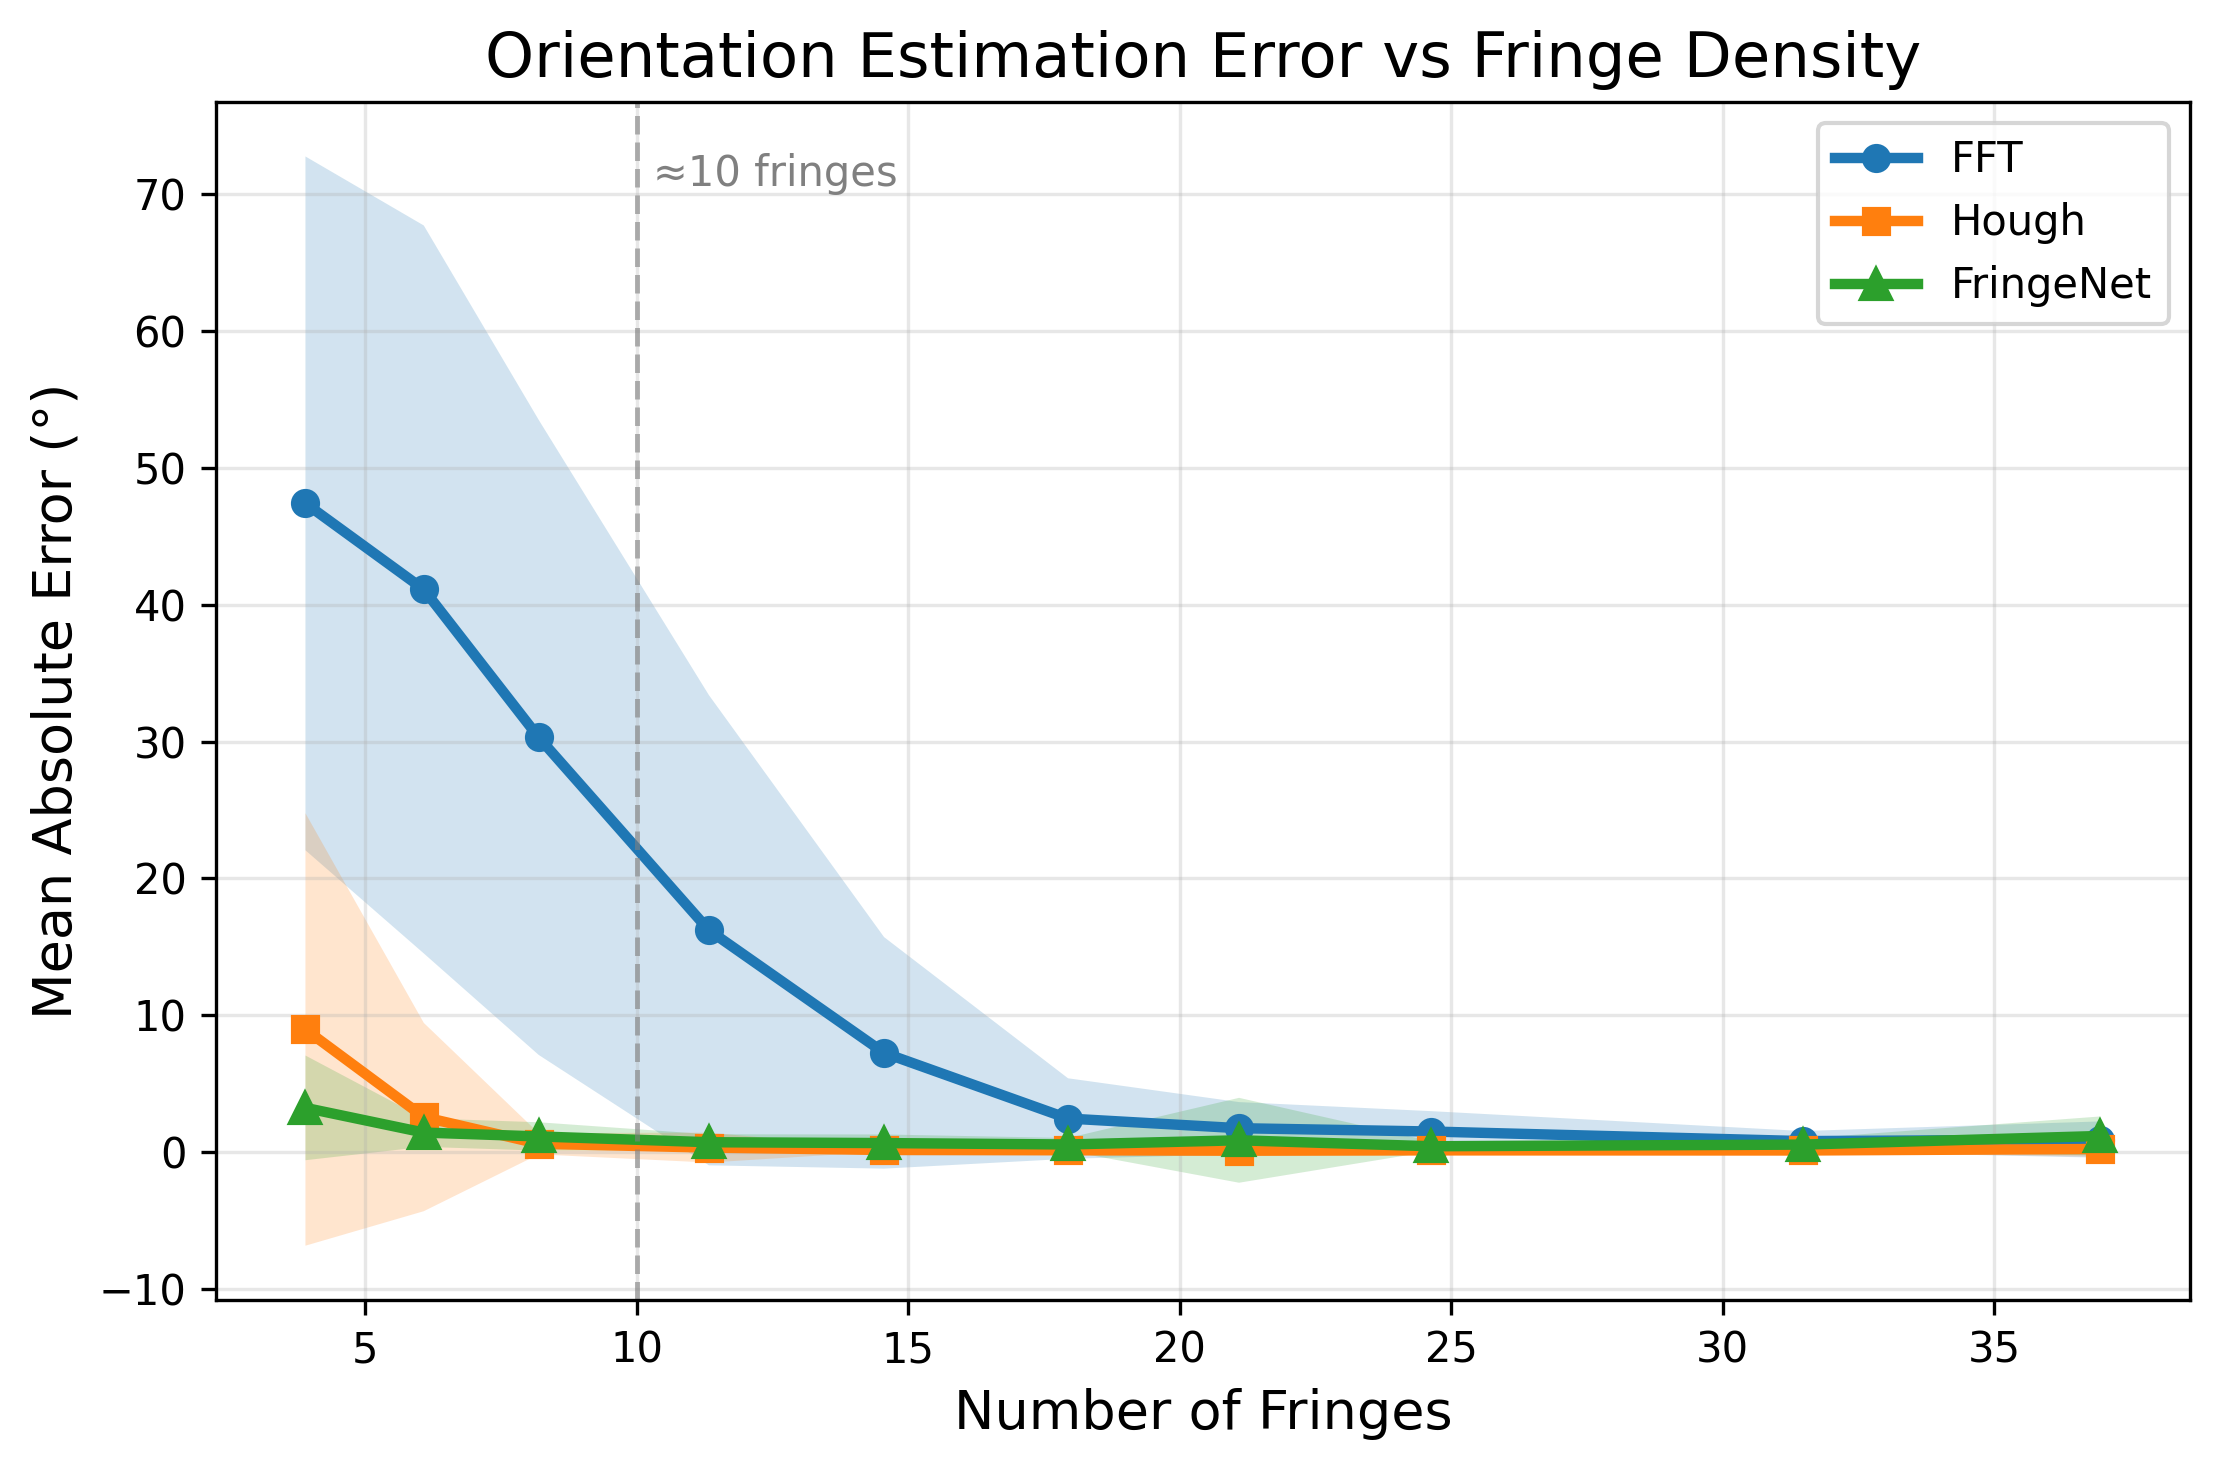

In [37]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7.5, 5), dpi=300)

# ===========================
# FFT
# ===========================
plt.plot(
    stats["Fringe"],
    stats["FFT_mean"],
    'o-',
    linewidth=2.5,
    markersize=6,
    label="FFT"
)

plt.fill_between(
    stats["Fringe"],
    stats["FFT_mean"] - stats["FFT_std"],
    stats["FFT_mean"] + stats["FFT_std"],
    alpha=0.20
)

# ===========================
# Hough
# ===========================
plt.plot(
    stats["Fringe"],
    stats["Hough_mean"],
    's-',
    linewidth=2.5,
    markersize=6,
    label="Hough"
)

plt.fill_between(
    stats["Fringe"],
    stats["Hough_mean"] - stats["Hough_std"],
    stats["Hough_mean"] + stats["Hough_std"],
    alpha=0.20
)

# ===========================
# FringeNet
# ===========================
plt.plot(
    stats["Fringe"],
    stats["CNN_mean"],
    '^-',
    linewidth=2.5,
    markersize=7,
    label="FringeNet"
)

plt.fill_between(
    stats["Fringe"],
    stats["CNN_mean"] - stats["CNN_std"],
    stats["CNN_mean"] + stats["CNN_std"],
    alpha=0.20
)

# Optional: indicate transition region
plt.axvline(
    10,
    linestyle="--",
    linewidth=1.2,
    color="gray",
    alpha=0.6
)

plt.text(
    10.3,
    plt.ylim()[1]*0.92,
    "≈10 fringes",
    fontsize=10,
    color="gray"
)

plt.xlabel("Number of Fringes", fontsize=13)
plt.ylabel("Mean Absolute Error (°)", fontsize=13)

plt.title("Orientation Estimation Error vs Fringe Density", fontsize=15)

plt.grid(True, alpha=0.3)

plt.legend(frameon=True)

plt.tight_layout()

plt.savefig(
    "MAE_vs_FringeDensity_Shaded.pdf",
    bbox_inches="tight"
)

plt.show()

In [38]:
stats = (
    plot_df
    .groupby("FringeBin")
    .agg(
        Fringe=("n_fringes","mean"),

        FFT_mean=("FFT_MAE","mean"),
        FFT_std=("FFT_MAE","std"),

        Hough_mean=("Hough_MAE","mean"),
        Hough_std=("Hough_MAE","std"),

        CNN_mean=("CNN_MAE","mean"),
        CNN_std=("CNN_MAE","std"),

        N=("n_fringes","size")
    )
)

stats["FFT_sem"] = stats["FFT_std"] / np.sqrt(stats["N"])
stats["Hough_sem"] = stats["Hough_std"] / np.sqrt(stats["N"])
stats["CNN_sem"] = stats["CNN_std"] / np.sqrt(stats["N"])

C:\Users\admin\AppData\Local\Temp\ipykernel_11780\572108349.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("FringeBin")


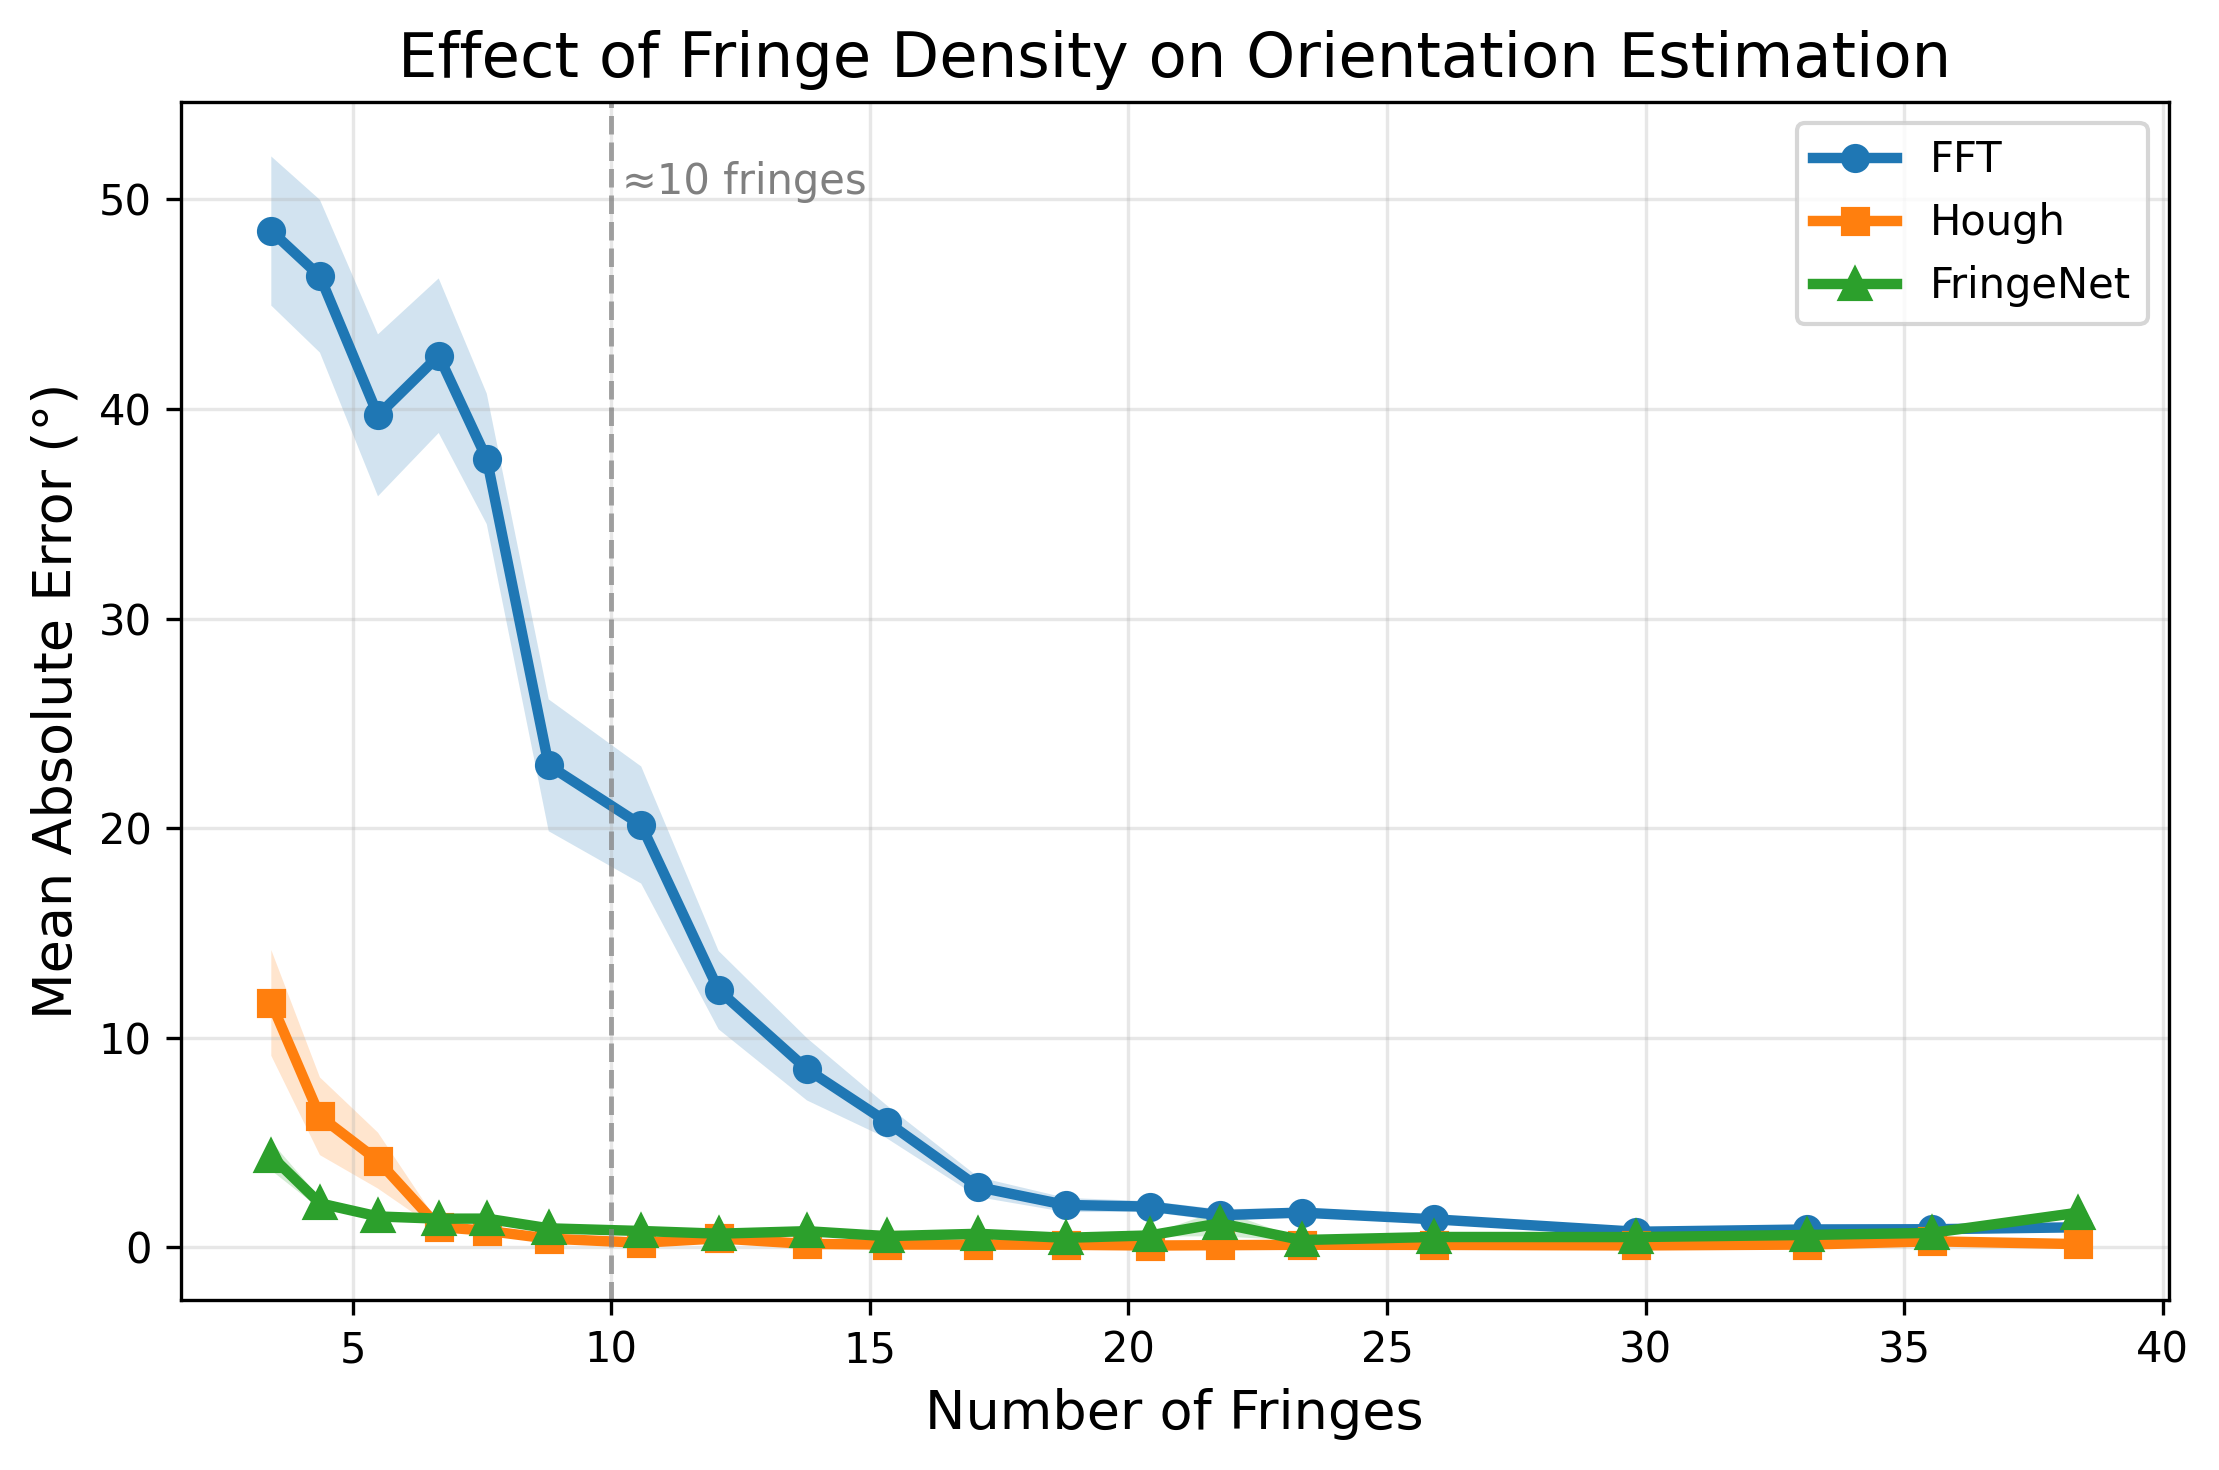

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7.5, 5), dpi=300)

# FFT
plt.plot(
    stats["Fringe"],
    stats["FFT_mean"],
    'o-',
    linewidth=2.5,
    markersize=6,
    label="FFT"
)

plt.fill_between(
    stats["Fringe"],
    stats["FFT_mean"] - stats["FFT_sem"],
    stats["FFT_mean"] + stats["FFT_sem"],
    alpha=0.2
)

# Hough
plt.plot(
    stats["Fringe"],
    stats["Hough_mean"],
    's-',
    linewidth=2.5,
    markersize=6,
    label="Hough"
)

plt.fill_between(
    stats["Fringe"],
    stats["Hough_mean"] - stats["Hough_sem"],
    stats["Hough_mean"] + stats["Hough_sem"],
    alpha=0.2
)

# FringeNet
plt.plot(
    stats["Fringe"],
    stats["CNN_mean"],
    '^-',
    linewidth=2.5,
    markersize=7,
    label="FringeNet"
)

plt.fill_between(
    stats["Fringe"],
    stats["CNN_mean"] - stats["CNN_sem"],
    stats["CNN_mean"] + stats["CNN_sem"],
    alpha=0.2
)

# Optional threshold line
plt.axvline(
    10,
    linestyle="--",
    color="gray",
    linewidth=1.2,
    alpha=0.7
)

plt.text(
    10.2,
    plt.ylim()[1]*0.92,
    "≈10 fringes",
    fontsize=10,
    color="gray"
)

plt.xlabel("Number of Fringes", fontsize=13)
plt.ylabel("Mean Absolute Error (°)", fontsize=13)
plt.title("Effect of Fringe Density on Orientation Estimation", fontsize=15)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig("MAE_vs_FringeDensity_SEM.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
plot_df["FringeBin"] = pd.qcut(
    plot_df["n_fringes"],
    q=15,
    duplicates="drop"
)